# Scoring cuantitativo de fondos mutuos USA

**Prueba tecnica — Analista de Renta Variable Internacional, AFP Habitat**

*David Gonzalez — FEN, Universidad de Chile*

---

**Objetivo:** construir un sistema cuantitativo que asigne un puntaje a cada fondo
del universo para informar la decision de inversion, distinguiendo fondos atractivos
de poco atractivos.

**Target elegido:** percentil cross-seccional del **Sortino ratio forward a 6 meses**
(`target_sortino_rank_6m`). La intuicion detras de esta eleccion es que el Sortino
penaliza solo la volatilidad a la baja — para un fondo de pension, la volatilidad
al alza no deberia considerarse riesgo en el mismo sentido.

**Filosofia:** modelo explicativo con validacion predictiva. ElasticNet como
primario (coeficientes interpretables, defendibles ante comite) + LightGBM como
sanity check no-lineal.

### Enfoque predictivo vs explicativo

La pregunta que guia este trabajo es si un modelo relativamente simple puede
capturar senales utiles para seleccionar fondos, y al mismo tiempo ser lo
suficientemente transparente como para justificarse ante un comite de inversiones.
En finanzas aplicadas, la tension entre modelos predictivos y explicativos es
permanente, y para una AFP ambas dimensiones parecen ser requisito.

Desde la dimension explicativa, una AFP necesita poder argumentar *por que*
selecciono ciertos fondos — "el modelo dijo" no basta. Hay que poder decir
algo como: "el modelo tiende a penalizar fee alto y a premiar consistencia de
retorno ajustada por riesgo bajista, que son principios de inversion razonables."
Los coeficientes del ElasticNet facilitan esto: cada uno mide cuanto cambia
el score al mover una feature un desvio estandar, lo que permite una auditoria
directa de la logica del modelo.

Sin embargo, sin validacion fuera de muestra estricta (walk-forward, embargo,
bootstrap CI), un modelo explicativo corre el riesgo de ser una racionalizacion
post-hoc — coeficientes que "hacen sentido" pero que no necesariamente
generalizan a datos futuros. La validacion predictiva funciona como antidoto
contra este tipo de sobreajuste narrativo.

Dado lo anterior, el ElasticNet parece ofrecer un equilibrio razonable entre
ambas dimensiones. Un modelo mas complejo (deep learning, ensemble de gradient
boosting) podria mejorar el IC en algunos puntos marginales, pero a costa de
perder interpretabilidad — algo dificil de justificar en un contexto de
gobernanza de inversiones. El ElasticNet es suficientemente flexible para
capturar senales lineales con regularizacion, y suficientemente simple para
que cada prediccion sea auditable.

**Reproducibilidad:**
```bash
pip install -r requirements.txt         # instalar dependencias
python -m scripts.run_all               # pipeline completo (requiere assets/usa_fondos_pp.sqlite)
jupyter notebook notebooks/informe.ipynb
```

*Nota: la primera celda de codigo instala automaticamente las dependencias
necesarias para ejecutar este notebook. No se requiere `uv` ni ningun
package manager especifico — basta con Python >=3.12.*

In [65]:
# --- Instalacion automatica de dependencias ---
import subprocess, sys
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "pandas>=2.0", "numpy>=1.26", "matplotlib>=3.8",
    "seaborn>=0.13", "pyarrow>=14",
])

0

In [66]:
import json
import sqlite3
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
sns.set_theme(style="whitegrid", palette="muted", font_scale=0.95)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130,
                      "axes.spines.top": False, "axes.spines.right": False})

# Rutas del proyecto
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = ROOT / "assets" / "usa_fondos_pp.sqlite"
ARTIFACTS = ROOT / "artifacts"
APP_DATA = ROOT / "app" / "backend" / "data"

# Para importar src/
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Raiz del proyecto: {ROOT}")
print(f"Base de datos: {DB_PATH} (existe: {DB_PATH.exists()})")

Raiz del proyecto: C:\Users\dgonz\PycharmProjects\Blooomberg
Base de datos: C:\Users\dgonz\PycharmProjects\Blooomberg\assets\usa_fondos_pp.sqlite (existe: True)


### Estructura del notebook

Este notebook es un **informe para el evaluador** — muestra versiones
simplificadas de las transformaciones clave para que se pueda seguir el
razonamiento paso a paso. El pipeline de produccion (modular, reutilizable)
vive en `src/` y se ejecuta via `scripts/01..05`:

```
01_build_features     → panel_raw.parquet    (datos diarios → panel mensual)
02_eda_report         → plots/               (graficos exploratorios)
03_build_features_full→ panel_features.parquet(32 features + targets)
04_train_and_evaluate → scores, metrics      (walk-forward, modelos, CI)
05_build_app_data     → app/backend/data/    (JSONs para el dashboard)
```

Las secciones que involucran carga de datos y construccion de features
reproducen el codigo inline con fines didacticos. Las secciones pesadas
(entrenamiento, walk-forward, metricas de evaluacion) **no se re-ejecutan**:
el notebook carga los artefactos pre-computados (`scores.parquet`,
`metrics.json`, etc.) y los presenta con visualizaciones y narrativa.

En cada seccion se incluyen comentarios que referencian el modulo `src/`
correspondiente, para que quien revise pueda navegar al codigo de produccion.

---
## 1. Carga de datos desde SQL

El dataset vive en una base SQLite (`assets/usa_fondos_pp.sqlite`, ~80 MB,
no versionada en git). Contiene tres tablas:

| Tabla | Contenido |
|---|---|
| `historico` | Precio diario (NAV) y eventos de capital por fondo |
| `fees` | Fee anual reportado (solo desde 2024-01-31) |
| `subyacentes` | Concentracion del portafolio (n_instrumentos, pct_acum) |

In [67]:
# --- Tabla 1: historico ---
# En el pipeline, la carga y limpieza la hace src/data.py → load_historico()
con = sqlite3.connect(DB_PATH)

historico = pd.read_sql(
    "SELECT fecha, securities AS fondo, precio, evento_pct FROM historico",
    con, parse_dates=["fecha"]
)
historico = historico.dropna(subset=["precio"]).sort_values(["fondo", "fecha"]).reset_index(drop=True)

print(f"historico: {historico.shape[0]:,} filas x {historico.shape[1]} columnas")
print(f"Fondos: {historico['fondo'].nunique()}")
print(f"Rango: {historico['fecha'].min().date()} -> {historico['fecha'].max().date()}")
historico.head(8)

historico: 1,201,276 filas x 4 columnas
Fondos: 277
Rango: 1988-11-17 -> 2026-05-01


,fecha,fondo,precio,evento_pct
0,2005-10-03,FONDO_0001,43.15,0.0
1,2005-10-04,FONDO_0001,43.35,0.0
2,2005-10-05,FONDO_0001,43.27,0.0
3,2005-10-06,FONDO_0001,42.68,0.0
4,2005-10-07,FONDO_0001,42.05,0.0
5,2005-10-10,FONDO_0001,42.07,0.0
6,2005-10-11,FONDO_0001,41.77,0.0
7,2005-10-12,FONDO_0001,41.67,0.0


In [68]:
# --- Tabla 2: fees ---
fees = pd.read_sql("SELECT fecha, fondo, fee FROM fees", con, parse_dates=["fecha"])
fees = fees.dropna(subset=["fee"]).query("fee > 0")

print(f"fees: {fees.shape[0]:,} filas")
print(f"Fondos con fee reportado: {fees['fondo'].nunique()}")
print(f"Rango: {fees['fecha'].min().date()} -> {fees['fecha'].max().date()}")
fees.describe()

fees: 66,491 filas
Fondos con fee reportado: 274
Rango: 2024-01-01 -> 2026-04-09


,fecha,fee
count,66491,66491.000000
mean,2025-01-08 16:22:54.357432,0.321389
min,2024-01-01 00:00:00,0.020000
25%,2024-09-02 00:00:00,0.080000
50%,2025-01-01 00:00:00,0.250000
75%,2025-05-01 00:00:00,0.390000
max,2026-04-09 00:00:00,3.000000
std,NaN,0.348581


In [69]:
# --- Tabla 3: subyacentes ---
subyacentes = pd.read_sql(
    "SELECT fecha, nemo_fondo AS fondo, pct_acum, n_instrumentos FROM subyacentes",
    con, parse_dates=["fecha"]
)
con.close()

print(f"subyacentes: {subyacentes.shape[0]:,} filas")
print(f"Fondos: {subyacentes['fondo'].nunique()}")
subyacentes.describe()

subyacentes: 129 filas
Fondos: 129


,fecha,pct_acum,n_instrumentos
count,129,129.000000,129.000000
mean,2023-06-24 11:09:46.046511,0.318045,23.775194
min,2012-04-30 00:00:00,0.300014,2.000000
25%,2023-04-26 00:00:00,0.303365,5.000000
50%,2025-10-28 00:00:00,0.308040,9.000000
75%,2025-10-28 00:00:00,0.321188,21.000000
max,2026-03-13 00:00:00,0.423616,161.000000
std,NaN,0.024811,34.477629


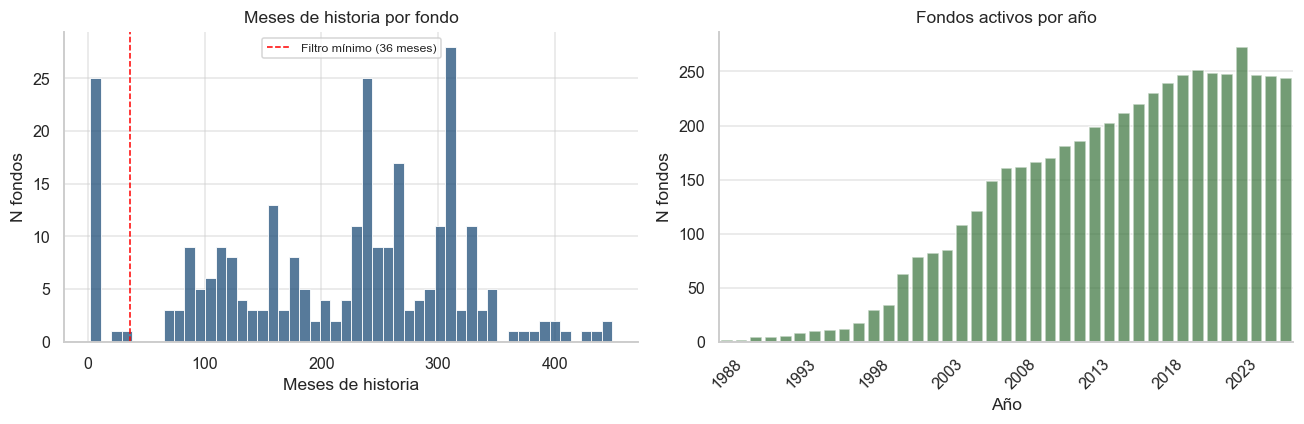

In [70]:
# Distribucion de meses de historia por fondo — informa sobre la profundidad
# del universo y anticipa el filtro de >=36 meses que se aplica mas adelante
meses_por_fondo = historico.groupby("fondo")["fecha"].apply(
    lambda s: (s.max() - s.min()).days / 30.44
).rename("meses_hist")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(meses_por_fondo, bins=50, ax=axes[0], color="#1f4e79")
axes[0].set_title("Meses de historia por fondo")
axes[0].set_xlabel("Meses de historia")
axes[0].set_ylabel("N fondos")
axes[0].axvline(36, color="red", ls="--", lw=1, label="Filtro mínimo (36 meses)")
axes[0].legend(fontsize=8)

# Fondos activos por año
fondos_por_anio = (
    historico.assign(anio=historico["fecha"].dt.year)
    .groupby("anio")["fondo"].nunique()
)
sns.barplot(x=fondos_por_anio.index, y=fondos_por_anio.values, ax=axes[1], color="#2e7d32", alpha=0.7)
axes[1].set_title("Fondos activos por año")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("N fondos")
axes[1].tick_params(axis="x", rotation=45)
# Mostrar solo cada 5 años
ticks = axes[1].get_xticks()
axes[1].set_xticks(ticks[::5])

fig.tight_layout()

**Observaciones:**

Lo que se observa es un universo de 277 fondos con entradas distribuidas desde 1988.
La mayoria tiene entre 100 y 400 meses de historia — la linea roja marca el filtro
minimo de 36 meses que se aplica mas adelante en el modelado. Vale la pena notar
que el universo activo crece fuertemente a partir de ~2000 y parece estabilizarse
alrededor de 2010.

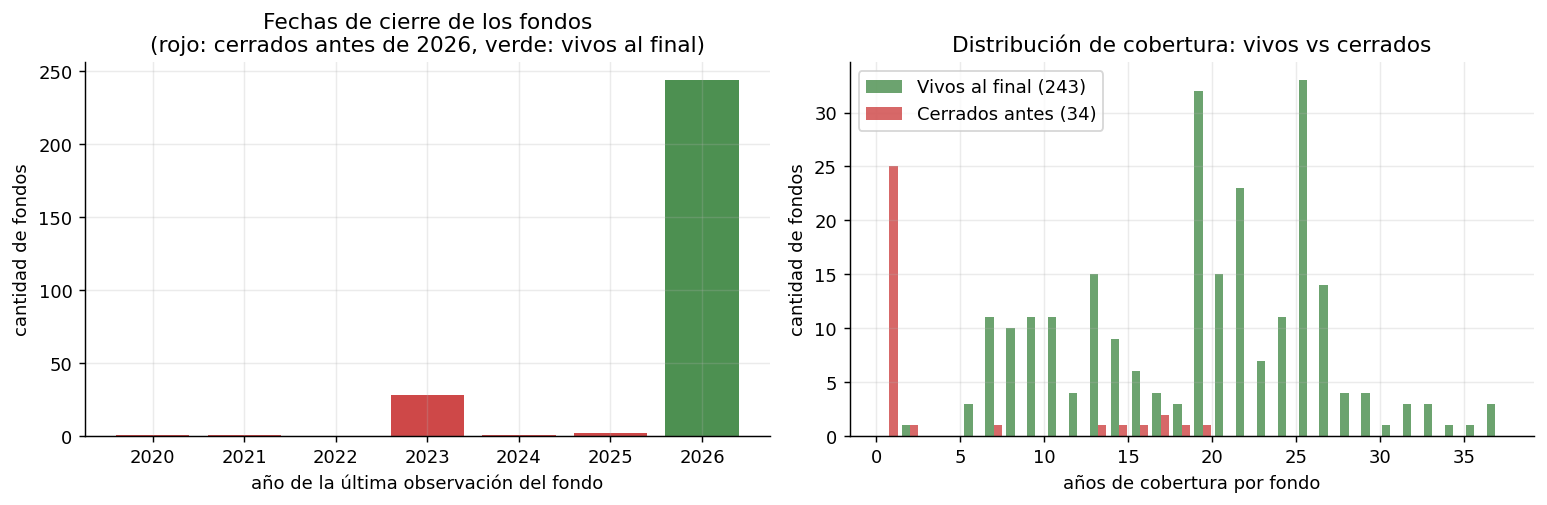

In [71]:
# Survivorship bias: distribucion de fondos vivos/muertos
from IPython.display import Image
Image(filename=str(ARTIFACTS / "plots" / "survivorship.png"))

**Survivorship bias detectado:** 87.7% de los fondos llegan vivos al final del
dataset (mayo 2026). Los 34 "muertos" tienen mediana de cobertura de solo 2
meses — lo que sugiere que el dataset es un snapshot del universo vigente al
momento de captura, no una historia completa con quiebras reales. El filtro de
cobertura minima >= 36 meses excluye a la mayoria de los muertos cortos.
Implicacion: el "retorno promedio del universo" esta sesgado al alza; pero como
la AFP tambien selecciona entre fondos vivos, el sesgo no invalida el modelo —
solo afecta como se interpretan metricas absolutas.

---
## 2. Retorno total y panel mensual

El retorno total que recibe el inversionista combina dos componentes:

$$r^{total}_t = \frac{P_t}{P_{t-1}} - 1 + \text{evento\_pct}_t$$

Donde `evento_pct` captura distribuciones de capital (dividendos, capital gains).
Sin este componente, se subestima el retorno en fondos con distribuciones recurrentes.

In [72]:
# Paso 1: retorno por variacion de precio (NAV day-over-day)
# En el pipeline, este calculo lo hace src/data.py → compute_daily_total_return()
historico = historico.sort_values(["fondo", "fecha"]).reset_index(drop=True)
historico["ret_precio"] = historico.groupby("fondo")["precio"].pct_change()

# Paso 2: retorno total crudo = variacion de precio + evento de capital
historico["ret_total_raw"] = historico["ret_precio"].fillna(0) + historico["evento_pct"].fillna(0)

# Paso 3: winsorizacion del retorno total al p99.5
# Se winsoriza el retorno TOTAL (no solo el evento) porque en eventos de
# split/reverse-split el precio cae y el evento compensa — winsorizar solo
# el evento destruye la cancelacion natural y genera drawdowns ficticios
cap = historico["ret_total_raw"].replace(0, np.nan).abs().quantile(0.995)
historico["ret_total"] = historico["ret_total_raw"].clip(lower=-cap, upper=cap)
print(f"Cap de winsorizacion: +/-{cap:.4f} ({cap*100:.2f}%)")

# La primera observacion de cada fondo no tiene retorno calculable
historico.loc[historico.groupby("fondo").head(1).index, "ret_total"] = np.nan

Cap de winsorizacion: +/-0.0625 (6.25%)


In [73]:
# Paso 4: Total Return Index (TRI) — normalizado a 1.0 en la primera obs
historico["one_plus_r"] = 1 + historico["ret_total"].fillna(0)
historico["tri"] = historico.groupby("fondo")["one_plus_r"].cumprod()

# Paso 5: agregacion a mensual — ultimo TRI del mes
historico["mes"] = historico["fecha"].dt.to_period("M").dt.to_timestamp("M")
eom = (
    historico.sort_values("fecha")
    .groupby(["fondo", "mes"])
    .tail(1)[["fondo", "mes", "tri"]]
    .rename(columns={"tri": "tri_eom"})
)
# Retorno mensual = variacion del TRI entre cierres de mes consecutivos
eom["ret_mensual"] = eom.groupby("fondo")["tri_eom"].pct_change()

print(f"Panel mensual: {eom.shape[0]:,} observaciones fondo-mes")
print(f"Fondos: {eom['fondo'].nunique()}, Meses: {eom['mes'].nunique()}")

Panel mensual: 58,396 observaciones fondo-mes
Fondos: 277, Meses: 451


### Features intra-mes: microestructura desde datos diarios

La idea detras de estas features es que el retorno mensual agregado pierde
informacion sobre como se distribuyo el movimiento dentro del mes. Un fondo
que cayo 5% en un solo dia y se recupero lentamente durante las tres semanas
siguientes tiene el mismo retorno mensual que uno con movimientos suaves —
pero la dinamica intra-mes sugiere cosas muy distintas sobre la liquidez y
el riesgo del fondo. Las features intra-mes buscan capturar estas propiedades
de microestructura que solo son observables en datos diarios:

- **`vol_intrames`**: volatilidad diaria dentro del mes — busca capturar
  regimenes de alta incertidumbre (e.g., meses con un solo dia de crash
  y recuperacion).
- **`autocorr_diaria`**: autocorrelacion de lag-1 del retorno diario.
  Valores altos podrian sugerir pricing stale o subyacentes iliquidos.
- **`ratio_dias_cero`**: fraccion de dias sin movimiento de precio.
  Proxy de iliquidez del fondo o de sus activos subyacentes.
- **`evento_pct_mes`**: suma de eventos de capital en el mes (dividendos,
  capital gains). Permite distinguir fondos de acumulacion vs distribucion.

In [74]:
# Paso 6: features intra-mes (calculadas desde datos diarios)
daily = historico.dropna(subset=["ret_total"]).copy()
daily["mes_agg"] = daily["fecha"].dt.to_period("M").dt.to_timestamp("M")

def _agg_intrames(g):
    """Features intra-mes por fondo-mes."""
    r = g["ret_total"]
    n = len(r)
    return pd.Series({
        "vol_intrames": r.std() if n >= 2 else np.nan,
        "autocorr_diaria": r.autocorr(lag=1) if n >= 5 else np.nan,
        "ratio_dias_cero": (r.abs() < 0.0001).mean(),
        "evento_pct_mes": g["evento_pct"].fillna(0).sum(),
    })

intra = daily.groupby(["fondo", "mes_agg"]).apply(_agg_intrames, include_groups=False).reset_index()
intra = intra.rename(columns={"mes_agg": "mes"})

# Merge al panel mensual
panel_raw = eom.merge(intra, on=["fondo", "mes"], how="left")
panel_raw = panel_raw.sort_values(["fondo", "mes"]).reset_index(drop=True)

print(f"panel_raw: {panel_raw.shape[0]:,} filas x {panel_raw.shape[1]} columnas")
panel_raw.head(10)

panel_raw: 58,396 filas x 8 columnas


,fondo,mes,tri_eom,ret_mensual,vol_intrames,autocorr_diaria,ratio_dias_cero,evento_pct_mes
0,FONDO_0001,2005-10-31,0.937249,NaN,0.018181,-0.345444,0.000000,0.000000
1,FONDO_0001,2005-11-30,0.972195,0.037286,0.006351,-0.088984,0.000000,0.000000
2,FONDO_0001,2005-12-31,0.962999,-0.009459,0.008195,-0.568122,0.142857,0.000000
3,FONDO_0001,2006-01-31,0.945131,-0.018554,0.007259,-0.140589,0.136364,0.000000
4,FONDO_0001,2006-02-28,0.978501,0.035307,0.010181,-0.557206,0.100000,0.000000
5,FONDO_0001,2006-03-31,0.960897,-0.017991,0.005362,-0.164498,0.043478,0.000000
6,FONDO_0001,2006-04-30,0.935350,-0.026587,0.005539,-0.476828,0.000000,0.008297
7,FONDO_0001,2006-05-31,0.916272,-0.020397,0.007806,-0.176999,0.090909,0.000000
8,FONDO_0001,2006-06-30,0.927401,0.012146,0.007634,-0.243491,0.045455,0.000000
9,FONDO_0001,2006-07-31,0.958231,0.033244,0.007373,-0.328975,0.047619,0.010163


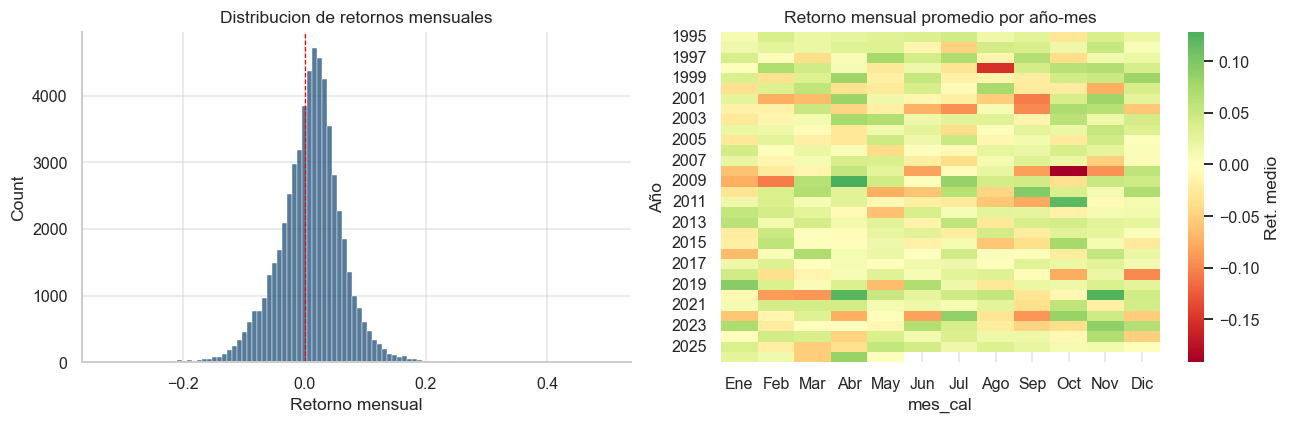

In [75]:
# Distribucion de retornos mensuales
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(panel_raw["ret_mensual"].dropna(), bins=100, ax=axes[0], color="#1f4e79")
axes[0].set_title("Distribucion de retornos mensuales")
axes[0].set_xlabel("Retorno mensual")
axes[0].axvline(0, color="red", ls="--", lw=0.8)

# Heatmap de retorno promedio por año y mes calendario
panel_raw["anio"] = panel_raw["mes"].dt.year
panel_raw["mes_cal"] = panel_raw["mes"].dt.month
ret_heatmap = panel_raw.pivot_table(
    values="ret_mensual", index="anio", columns="mes_cal", aggfunc="mean"
)
# Filtrar años con suficientes datos
ret_heatmap = ret_heatmap.loc[ret_heatmap.index >= 1995]
sns.heatmap(ret_heatmap, cmap="RdYlGn", center=0, ax=axes[1],
            xticklabels=["Ene","Feb","Mar","Abr","May","Jun",
                         "Jul","Ago","Sep","Oct","Nov","Dic"],
            cbar_kws={"label": "Ret. medio"})
axes[1].set_title("Retorno mensual promedio por año-mes")
axes[1].set_ylabel("Año")

# Limpiar columnas auxiliares
panel_raw = panel_raw.drop(columns=["anio", "mes_cal"])
fig.tight_layout()

**Observaciones:**

La distribucion de retornos mensuales resulta aproximadamente simetrica alrededor
de cero, con colas moderadas y una mediana ligeramente positiva (~0.5-1% mensual).
En el heatmap se distingue con claridad la crisis de 2008-2009 (rojos intensos) y
los periodos de bull market (2013, 2019, 2021). Lo interesante aqui es que las
features intra-mes (`vol_intrames`, `autocorr_diaria`, `ratio_dias_cero`) buscan
capturar propiedades de microestructura que tienden a perderse al agregar a mensual.

---
## 3. Imputacion de fees y concentracion

### Fee: solo reporta desde 2024, pero es estructural

El dataset reporta fees a partir de 2024-01-31 — el **89% del panel es NaN**.

**Interpretacion del campo `fee`:** los valores reportados en la tabla se
interpretan directamente como **fee anual** (expense ratio). Los valores
observados (mediana ~0.5-1.5%) son consistentes con los expense ratios
tipicos de fondos mutuos USA. Si se intentara anualizarlos (e.g.,
multiplicar por 12), los costos resultantes serian excesivos y no tendrian
sentido economico. Ademas, el valor se repite identico en cada reporte
mensual del mismo fondo — lo que confirma que es una tasa anual fija, no
un cobro mensual.

El fee de un mutual fund USA es estructuralmente estable:
la desviacion intra-fondo es $\approx 0$.

Estadisticas del fee intra-fondo:
  Mediana de std intra-fondo: 0.000000
  % fondos con std = 0: 74.1%
  Fondos con fee reportado: 274

Cobertura fee:
  Antes:  11.6%
  Despues: 97.8%


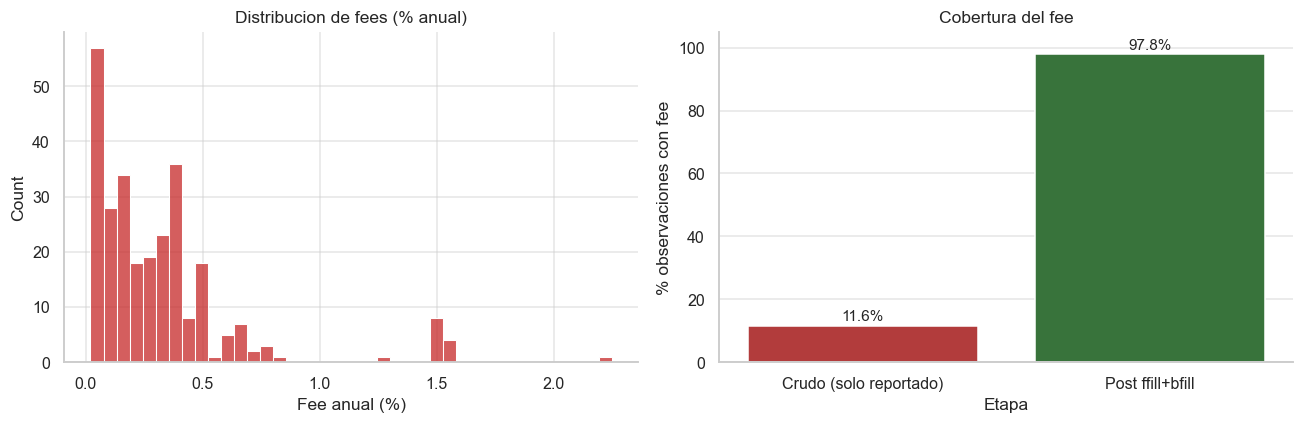

In [76]:
# Verificacion empirica: variabilidad del fee dentro de cada fondo
# En el pipeline, la imputacion la hace src/data.py → attach_fees()
fee_por_fondo = (
    fees.groupby("fondo")["fee"]
    .agg(["count", "mean", "std"])
    .rename(columns={"count": "n_obs", "mean": "fee_medio", "std": "fee_std"})
)
fee_por_fondo["fee_std"] = fee_por_fondo["fee_std"].fillna(0)

print("Estadisticas del fee intra-fondo:")
print(f"  Mediana de std intra-fondo: {fee_por_fondo['fee_std'].median():.6f}")
print(f"  % fondos con std = 0: {(fee_por_fondo['fee_std'] == 0).mean():.1%}")
print(f"  Fondos con fee reportado: {len(fee_por_fondo)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(fee_por_fondo["fee_medio"], bins=40, ax=axes[0], color="#c62828")
axes[0].set_title("Distribucion de fees (% anual)")
axes[0].set_xlabel("Fee anual (%)")

# Cobertura del fee antes y despues de imputacion
# Adjuntar fees al panel con ffill+bfill
fees_sorted = fees.sort_values(["fondo", "fecha"])
fees_eom = (
    fees_sorted.assign(mes=lambda x: x["fecha"].dt.to_period("M").dt.to_timestamp("M"))
    .groupby(["fondo", "mes"]).tail(1)[["fondo", "mes", "fee"]]
)
panel_fee = panel_raw[["fondo", "mes"]].merge(fees_eom, on=["fondo", "mes"], how="left")

cobertura_antes = panel_fee["fee"].notna().mean()
panel_fee["fee_observado"] = panel_fee["fee"].notna().astype(int)
panel_fee["fee"] = panel_fee.groupby("fondo")["fee"].transform(lambda s: s.ffill().bfill())
cobertura_despues = panel_fee["fee"].notna().mean()

bardata = pd.DataFrame({
    "Etapa": ["Crudo (solo reportado)", "Post ffill+bfill"],
    "Cobertura": [cobertura_antes * 100, cobertura_despues * 100]
})
sns.barplot(data=bardata, x="Etapa", y="Cobertura", ax=axes[1],
            palette=["#c62828", "#2e7d32"])
axes[1].set_title("Cobertura del fee")
axes[1].set_ylabel("% observaciones con fee")
axes[1].set_ylim(0, 105)
for i, v in enumerate(bardata["Cobertura"]):
    axes[1].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=10)

fig.tight_layout()

print(f"\nCobertura fee:")
print(f"  Antes:  {cobertura_antes:.1%}")
print(f"  Despues: {cobertura_despues:.1%}")

**Reflexion sobre la imputacion:** dado que la std intra-fondo es practicamente
cero, parece razonable asumir que el fee es estructuralmente constante en el
tiempo para cada fondo. Bajo este supuesto, aplicar `ffill+bfill` dentro de cada
fondo simplemente propaga el valor reportado en 2024+ hacia atras, llevando la
cobertura de ~11% a ~98%. Naturalmente, este supuesto podria no cumplirse para
fondos que hayan cambiado su estructura de costos en el pasado — pero la evidencia
disponible (std $\approx 0$) sugiere que es una aproximacion razonable. La flag
`fee_observado` (1 = dato original, 0 = imputado) permite al modelo distinguir
ambos casos, lo que en principio le da la opcion de ponderar distinto la
informacion segun su origen.

### Concentracion: n_instrumentos via forward-fill

`n_instrumentos` = minimo de holdings para acumular 30% del AUM (snapshot del portafolio).
En este caso solo se aplica `ffill` (no `bfill`) porque la composicion del
portafolio si varia en el tiempo — extrapolar hacia atras no seria justificable.

In [77]:
# Cobertura de concentracion
n_fondos_con_sub = subyacentes["fondo"].nunique()
n_fondos_total = historico["fondo"].nunique()
print(f"Fondos con datos de concentracion: {n_fondos_con_sub} de {n_fondos_total} "
      f"({n_fondos_con_sub/n_fondos_total:.0%})")
print(f"pct_acum: min={subyacentes['pct_acum'].min():.3f}, "
      f"max={subyacentes['pct_acum'].max():.3f}, "
      f"mediana={subyacentes['pct_acum'].median():.3f}")

Fondos con datos de concentracion: 129 de 277 (47%)
pct_acum: min=0.300, max=0.424, mediana=0.308


---
## 4. Feature engineering — 32 features

Todas las features son estrictamente **backward-looking** — usan solo
informacion disponible hasta la fecha de observacion. El unico elemento
forward-looking es el **target** (Sortino forward 6m), protegido por un
embargo igual al horizonte en el esquema walk-forward. La disciplina de
anti-leakage busca asegurar que ninguna feature "mire al futuro" — si eso ocurriera,
las metricas OOS se inflarian artificialmente y el modelo seria
inutilizable en produccion.

Las features se organizan en tres grupos:

| Grupo | N | Features | Intuicion |
|---|---|---|---|
| CORE | 14 | ret_1/3/6/12m, vol_12m, max_dd_12m, sharpe_12m, sortino_12m, vol_intrames, autocorr_diaria, ratio_dias_cero, skewness_12m, hit_rate_12m, distribution_yield_12m, persistencia_rank_12m | Momentum, riesgo, microestructura, consistencia |
| EXTENDED | 5 | fee, log_n_instrumentos, pct_acum, fee_observado, concentracion_disponible | Estructura del fondo + flags de imputacion |
| RANK | 13 | Percentil cross-seccional de 13 features | Normalizacion [0,1], robustez a regimenes |

**Total: 32 features.**

### Detalle de las 32 features

**CORE (14)** — desempeno historico del fondo:

| # | Feature | Descripcion | Importancia |
|---|---|---|---|
| 1 | `ret_1m` | Retorno compuesto ultimo mes | Momentum de corto plazo |
| 2 | `ret_3m` | Retorno compuesto ultimos 3 meses | Momentum intermedio |
| 3 | `ret_6m` | Retorno compuesto ultimos 6 meses | Momentum medio plazo |
| 4 | `ret_12m` | Retorno compuesto ultimos 12 meses | Momentum principal, predictor mas robusto |
| 5 | `vol_12m` | Volatilidad anualizada (std retornos 12m) | Riesgo total del fondo |
| 6 | `max_dd_12m` | Maxima caida pico-valle en 12 meses | Peor escenario historico reciente |
| 7 | `sharpe_12m` | Sharpe ratio anualizado 12m | Retorno ajustado por riesgo total |
| 8 | `vol_intrames` | Volatilidad diaria dentro del mes | Regimenes de alta incertidumbre intra-mes |
| 9 | `autocorr_diaria` | Autocorrelacion lag-1 del retorno diario | Proxy de pricing stale o iliquidez |
| 10 | `ratio_dias_cero` | Fraccion de dias sin movimiento de precio | Proxy de iliquidez del subyacente |
| 11 | `skewness_12m` | Asimetria de la distribucion de retornos 12m | Distingue fondos con colas asimétricas |
| 12 | `hit_rate_12m` | Fraccion de meses positivos en 12m | Consistencia del fondo |
| 13 | `distribution_yield_12m` | Suma de eventos de capital / precio (12m) | Estilo income vs growth |
| 14 | `persistencia_rank_12m` | Correlacion del ranking relativo en t vs t-12 | Estabilidad de la posicion en el universo |

**EXTENDED (5)** — estructura del fondo:

| # | Feature | Descripcion | Importancia |
|---|---|---|---|
| 15 | `fee` | Fee anual del fondo (expense ratio) | Costo garantizado, predictor de underperformance |
| 16 | `log_n_instrumentos` | Log del minimo de holdings para acumular 30% del AUM | Diversificacion vs concentracion |
| 17 | `pct_acum` | % exacto acumulado por esos holdings (siempre >= 30%) | Nivel de concentracion del portafolio |
| 18 | `fee_observado` | Flag: 1 si el fee fue reportado, 0 si imputado | Permite al modelo ponderar dato original vs imputado |
| 19 | `concentracion_disponible` | Flag: 1 si hay datos de concentracion | Idem para datos de holdings |

**RANK (13)** — percentil cross-seccional [0, 1] de cada feature dentro del mes.
Para cada mes, se toman todos los fondos activos y se rankea cada feature de
0 (peor/menor) a 1 (mejor/mayor). Por ejemplo, `ret_3m_rank = 0.85` significa
que ese fondo tuvo un retorno a 3 meses mayor que el 85% de los fondos del
universo *en ese mismo mes*. Esto normaliza la feature por el contexto de
mercado: un retorno de 5% a 3m puede ser excelente en una crisis (rank ~0.95)
y mediocre en un bull market (rank ~0.40). Las features rank aportan robustez
a cambios de regimen y eliminan diferencias de escala entre periodos:

| # | Feature | Feature base rankeada |
|---|---|---|
| 20 | `ret_3m_rank` | Momentum 3m relativo al universo |
| 21 | `ret_12m_rank` | Momentum 12m relativo al universo |
| 22 | `vol_12m_rank` | Volatilidad relativa |
| 23 | `sharpe_12m_rank` | Sharpe relativo |
| 24 | `max_dd_12m_rank` | Drawdown relativo (rank alto = menos profundo) |
| 25 | `fee_rank` | Fee relativo al universo |
| 26 | `log_n_instrumentos_rank` | Diversificacion relativa |
| 27 | `pct_acum_rank` | Concentracion relativa |
| 28 | `vol_intrames_rank` | Volatilidad intra-mes relativa |
| 29 | `autocorr_diaria_rank` | Iliquidez relativa |
| 30 | `ratio_dias_cero_rank` | Iliquidez relativa (dias sin movimiento) |
| 31 | `skewness_12m_rank` | Asimetria relativa |
| 32 | `hit_rate_12m_rank` | Consistencia relativa |

In [78]:
# Cargar panel completo con features (output del pipeline, script 03)
# Implementacion completa: src/features.py → build_features(), add_return_features(), etc.
panel = pd.read_parquet(ARTIFACTS / "panel_features.parquet")
from src.features import FEATURE_COLS, CORE_FEATURES, EXTENDED_FEATURES, RANK_FEATURES

print(f"panel_features: {panel.shape[0]:,} filas x {panel.shape[1]} columnas")
print(f"\n{'='*50}")
print(f"CORE ({len(CORE_FEATURES)}):")
for f in CORE_FEATURES:
    print(f"  - {f}")
print(f"\nEXTENDED ({len(EXTENDED_FEATURES)}):")
for f in EXTENDED_FEATURES:
    print(f"  - {f}")
print(f"\nRANK ({len(RANK_FEATURES)}):")
for f in RANK_FEATURES:
    print(f"  - {f}")
print(f"\nTotal features: {len(FEATURE_COLS)}")

panel_features: 58,396 filas x 61 columnas

CORE (14):
  - ret_1m
  - ret_3m
  - ret_6m
  - ret_12m
  - vol_12m
  - max_dd_12m
  - sharpe_12m
  - vol_intrames
  - autocorr_diaria
  - ratio_dias_cero
  - skewness_12m
  - hit_rate_12m
  - distribution_yield_12m
  - persistencia_rank_12m

EXTENDED (5):
  - fee
  - log_n_instrumentos
  - pct_acum
  - fee_observado
  - concentracion_disponible

RANK (13):
  - ret_3m_rank
  - ret_12m_rank
  - vol_12m_rank
  - sharpe_12m_rank
  - max_dd_12m_rank
  - fee_rank
  - log_n_instrumentos_rank
  - pct_acum_rank
  - vol_intrames_rank
  - autocorr_diaria_rank
  - ratio_dias_cero_rank
  - skewness_12m_rank
  - hit_rate_12m_rank

Total features: 32


In [79]:
# Ejemplo: construccion de retornos compuestos trailing (inline, didactico)
# Implementacion completa: src/features.py → add_return_features()
ejemplo = panel_raw[panel_raw["fondo"] == panel_raw["fondo"].iloc[0]].copy()
for h in [1, 3, 6, 12]:
    # Retorno compuesto = prod(1 + r_i) - 1 sobre los ultimos h meses
    ejemplo[f"ret_{h}m"] = (
        (1 + ejemplo["ret_mensual"])
        .rolling(h, min_periods=h)
        .apply(np.prod, raw=True) - 1
    )
print(f"Retornos trailing para {ejemplo['fondo'].iloc[0]}:")
ejemplo[["mes", "ret_mensual", "ret_1m", "ret_3m", "ret_6m", "ret_12m"]].tail(10)

Retornos trailing para FONDO_0001:


,mes,ret_mensual,ret_1m,ret_3m,ret_6m,ret_12m
237,2025-07-31,0.044113,0.044113,0.042691,-0.081770,0.007194
238,2025-08-31,0.028359,0.028359,0.055532,-0.078959,0.026962
239,2025-09-30,0.005585,0.005585,0.079721,-0.015831,0.021529
240,2025-10-31,-0.003759,-0.003759,0.030216,0.074197,-0.001618
241,2025-11-30,0.024650,0.024650,0.026499,0.083503,-0.061503
242,2025-12-31,-0.009121,-0.009121,0.011487,0.092124,-0.007964
243,2026-01-31,0.044447,0.044447,0.060431,0.092472,0.003142
244,2026-02-28,0.038457,0.038457,0.074721,0.103200,0.016092
245,2026-03-31,-0.001067,-0.001067,0.083456,0.095902,0.078552
246,2026-04-30,0.012703,0.012703,0.050526,0.114011,0.196667


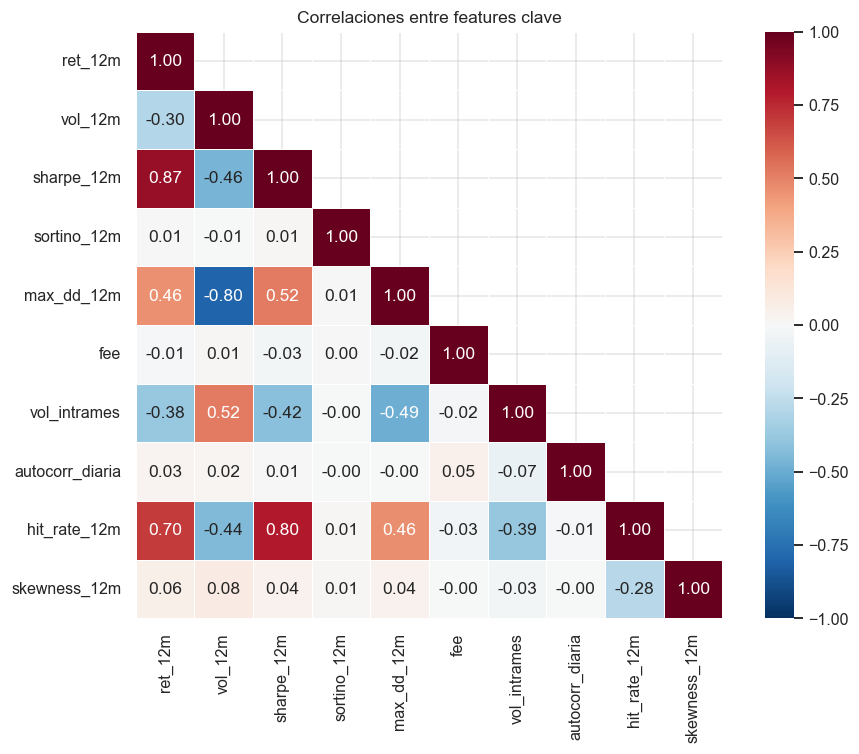

In [80]:
# Correlaciones entre features clave
features_para_corr = [
    "ret_12m", "vol_12m", "sharpe_12m", "sortino_12m", "max_dd_12m",
    "fee", "vol_intrames", "autocorr_diaria", "hit_rate_12m", "skewness_12m"
]
corr = panel[features_para_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=ax, vmin=-1, vmax=1, square=True, linewidths=0.5)
ax.set_title("Correlaciones entre features clave")
fig.tight_layout()

**Observaciones:**

Lo que se observa en la matriz es que `sharpe_12m` y `ret_12m` tienen correlacion
alta (~0.7-0.8) — ambos capturan momentum, pero sharpe ajusta por riesgo. Tambien
`vol_12m` y `max_dd_12m` aparecen correlacionados negativamente (drawdown mas
profundo = mas volatilidad), aunque ambos parecen aportar informacion complementaria.
Un punto interesante es que `fee` tiende a mostrar baja correlacion con las demas
features — lo que sugiere que el fee es una senal relativamente independiente
de underperformance futura.

### Estacionariedad de las features

Un supuesto importante de cualquier modelo predictivo es que las distribuciones
de las features se mantengan razonablemente estables entre entrenamiento y
prediccion. En este caso, hay razones para pensar que se cumple — al menos de
forma aproximada.

En primer lugar, las series de precios (NAV) son no estacionarias (raiz unitaria),
pero los retornos mensuales (`pct_change`) tienden a ser estacionarios y no
requieren diferenciacion adicional. Todas las features CORE se construyen sobre
retornos, no sobre precios, lo que parece razonable desde esta perspectiva.

En segundo lugar, las features rank son estacionarias por construccion. El
percentil cross-seccional se recalcula cada mes sobre los fondos activos en ese
momento — un rank de 0.8 siempre significa "top 20% de su cohorte",
independientemente del nivel absoluto del mercado. Esto ayuda a eliminar
tendencias y cambios de escala entre regimenes.

Finalmente, el esquema walk-forward con `max_train_months=120` (10 anos)
descarta observaciones anteriores, lo que en principio permite adaptarse a
quiebres estructurales (pre/post-2008, era de tasas cero, inflacion 2022+)
sin necesidad de asumir que los parametros son globalmente estables. Este
enfoque pragmatico parece preferible a tests formales de estacionariedad
(ADF, KPSS) que asumen estabilidad global — la ventana rolling reconoce
que los mercados cambian, en vez de pretender que no lo hacen.

---
## 5. Construccion del target: por que Sortino y no Sharpe

Esta es probablemente la decision metodologica mas importante del proyecto.

### Sharpe ratio
$$\text{Sharpe} = \frac{\bar{r} - r_f}{\sigma} \cdot \sqrt{12}$$

Penaliza **toda** volatilidad — incluyendo la volatilidad al alza. Un fondo
que sube mucho un mes y poco otro tiene Sharpe bajo, aunque haya ganado
consistentemente.

### Sortino ratio
$$\text{Sortino} = \frac{\bar{r} - r_f}{\sqrt{\frac{1}{n}\sum_{i=1}^{n} \min(r_i, 0)^2}} \cdot \sqrt{12}$$

Penaliza **solo la volatilidad a la baja** (downside deviation). La volatilidad
al alza no se considera riesgo — si un fondo sube 10% un mes y 1% otro, eso
es deseable, no penalizable.

### Por que Sortino para una AFP

Para una AFP, la volatilidad al alza no deberia considerarse riesgo — Sortino
captura esta asimetria al penalizar solo el downside, premiando fondos que ganan
asimetricamente arriba.

### Por que percentil y no valor absoluto

El target no es el Sortino forward en valor absoluto, sino su **percentil
cross-seccional** (`target_sortino_rank_6m`). Para cada mes $t$, se calcula
el Sortino forward 6m de todos los fondos activos y se rankea de 0 (peor)
a 1 (mejor). La razon: un Sortino de 2.0 en un mercado alcista (2021) no
es comparable a un Sortino de 2.0 en un mercado bajista (2008). El percentil
normaliza por el regimen de mercado — un fondo con rank 0.9 es el top 10%
*de su cohorte temporal*, independientemente del nivel absoluto.

Esto tambien evita que el modelo aprenda "reglas de regimen" en vez de
caracteristicas intrinsecas del fondo. Si el target fuera el Sortino
absoluto, el modelo aprenderia a predecir el mercado (facil en-muestra,
imposible fuera de muestra).

### Horizonte 6 meses

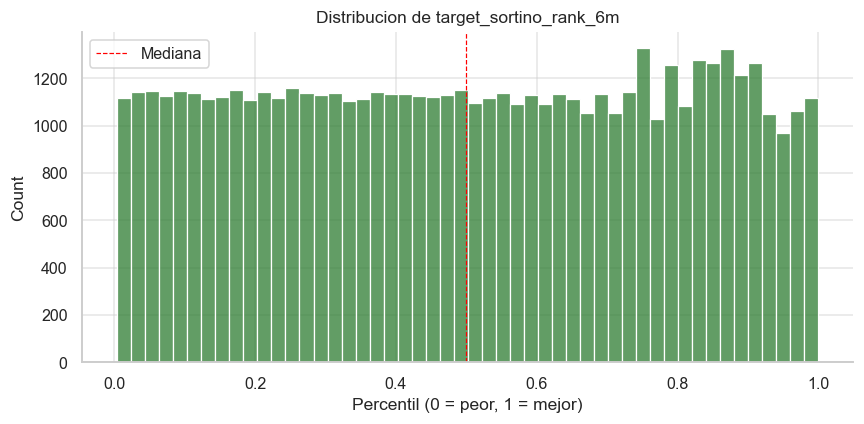

In [98]:
# Distribucion del target en el panel
# Horizonte = 6 meses, Sortino forward rankeado cross-seccionalmente
target_col = "target_sortino_rank_6m"

fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(panel[target_col].dropna(), bins=50, ax=ax, color="#2e7d32")
ax.set_title(f"Distribucion de {target_col}")
ax.set_xlabel("Percentil (0 = peor, 1 = mejor)")
ax.axvline(0.5, color="red", ls="--", lw=0.8, label="Mediana")
ax.legend()

fig.tight_layout()

**Observacion:** el target `target_sortino_rank_6m` tiene distribucion uniforme
por construccion (es un percentil rank). Esto confirma que el ranking esta bien
construido — cada posicion relativa tiene la misma frecuencia.

### Horizonte 6 meses (desde el analisis del target)

- **3m**: ruidoso (solo 3 obs para downside deviation, rankings inestables).
- **12m**: lento, embargo de 12m reduce folds (~15 vs 29).
- **6m**: equilibrio — 29 folds, 6 obs para downside risk.

---
## 6. Esquema de validacion walk-forward

El esquema de validacion es **rolling window walk-forward** con embargo
(ventana de 10 años, `max_train_months=120`). Simula como se usaria el
modelo en produccion: siempre entrenando con datos recientes y evaluando
en datos futuros. La ventana rolling se adapta a cambios de regimen de
mercado (pre/post-2008, era de tasas cero, inflacion 2022+), descartando
datos antiguos que podrian diluir la senal.

```
[--- TRAIN (rolling, 10a max) ---][--- EMBARGO (6m) ---][--- VAL (12m) ---]
```

**Embargo = horizonte del target (6m):** dado que el target mira 6 meses
adelante, sin embargo las ventanas de target del train y validacion se
solaparian, contaminando la evaluacion.

In [99]:
# Cargar diagnosticos de folds
# El walk-forward esta implementado en src/splits.py → walk_forward_folds()
diag = pd.read_csv(ARTIFACTS / "fold_diagnostics.csv")
print(f"Total folds: {len(diag)}")
print(f"Primer fold: val {diag.iloc[0]['val_start']} -> {diag.iloc[0]['val_end']}")
print(f"Ultimo fold: val {diag.iloc[-1]['val_start']} -> {diag.iloc[-1]['val_end']}")
print()
diag[["fold", "train_start", "train_end", "val_start", "val_end", "n_train", "n_val"]]

Total folds: 29
Primer fold: val 1996-05-31 -> 1997-04-30
Ultimo fold: val 2024-05-31 -> 2025-04-30



,fold,train_start,train_end,val_start,val_end,n_train,n_val
0,0,1990-11-30,1995-10-31,1996-05-31,1997-04-30,246,112
1,1,1990-11-30,1996-10-31,1997-05-31,1998-04-30,351,122
2,2,1990-11-30,1997-10-31,1998-05-31,1999-04-30,469,132
3,3,1990-11-30,1998-10-31,1999-05-31,2000-04-30,597,186
4,4,1990-11-30,1999-10-31,2000-05-31,2001-04-30,748,292
5,5,1990-11-30,2000-10-31,2001-05-31,2002-04-30,969,392
6,6,1991-11-30,2001-10-31,2002-05-31,2003-04-30,1310,717
7,7,1992-11-30,2002-10-31,2003-05-31,2004-04-30,1802,906
8,8,1993-11-30,2003-10-31,2004-05-31,2005-04-30,2580,968
9,9,1994-11-30,2004-10-31,2005-05-31,2006-04-30,3469,1043


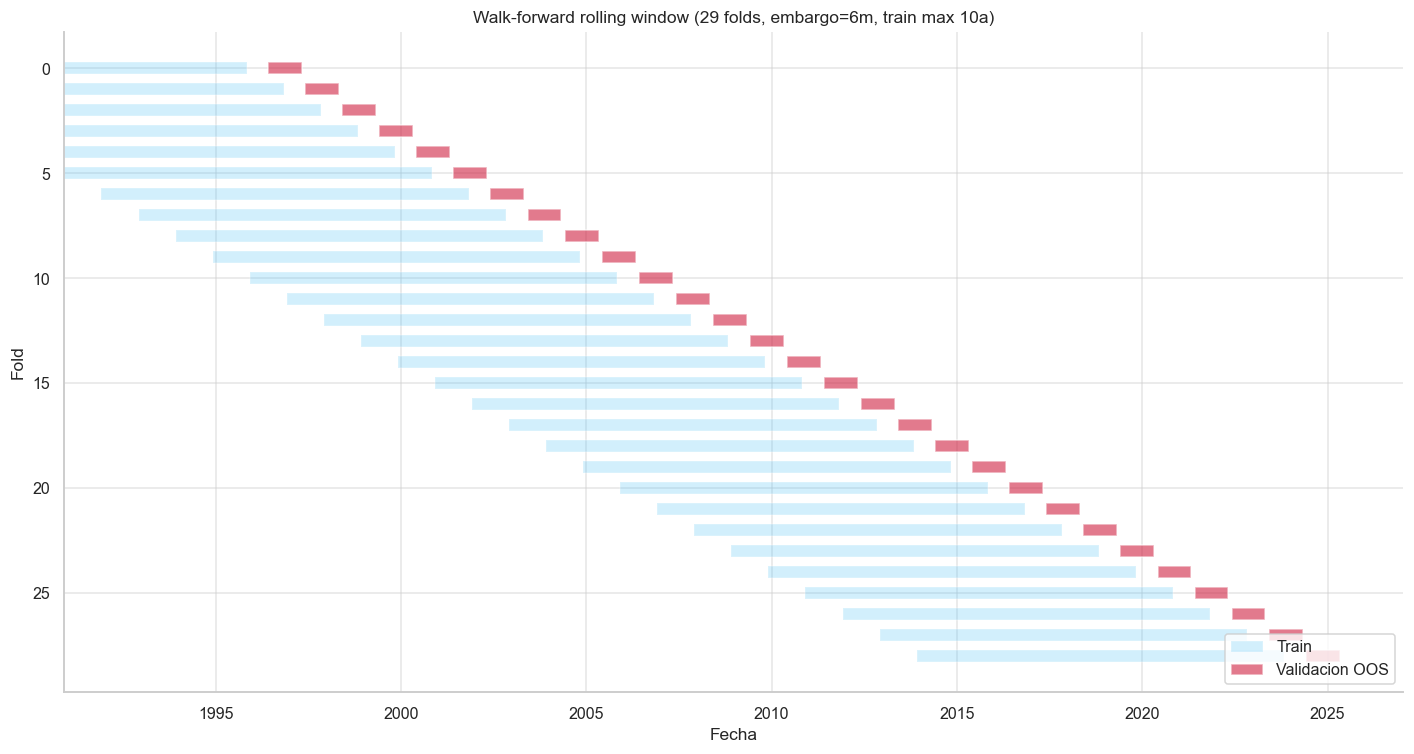

In [83]:
# Gantt chart de folds walk-forward
fig, ax = plt.subplots(figsize=(13, 7))

for _, row in diag.iterrows():
    fold = row["fold"]
    # Barra de train
    t_start = pd.Timestamp(row["train_start"])
    t_end = pd.Timestamp(row["train_end"])
    ax.barh(fold, t_end - t_start, left=t_start,
            color="#4fc3f7", alpha=0.25, height=0.6,
            label="Train" if fold == 0 else "")
    # Barra de validacion
    v_start = pd.Timestamp(row["val_start"])
    v_end = pd.Timestamp(row["val_end"])
    ax.barh(fold, v_end - v_start, left=v_start,
            color="#CF2141", alpha=0.6, height=0.6,
            label="Validacion OOS" if fold == 0 else "")

ax.set_ylabel("Fold")
ax.set_xlabel("Fecha")
ax.set_title(f"Walk-forward rolling window ({len(diag)} folds, embargo=6m, train max 10a)")
ax.legend(loc="lower right")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(5))
fig.tight_layout()

Cada fold desliza la ventana de entrenamiento (maximo 120 meses = 10 anos) y
evalua el siguiente bloque de 12 meses tras un gap de 6 meses (embargo). En los
primeros folds el train crece hasta alcanzar el tope de 120 meses; despues se
estabiliza y la ventana se desliza manteniendo solo datos recientes.

Una alternativa natural seria usar k-fold CV, pero en datos con dependencia
temporal esto mezclaria futuro con pasado — violando la causalidad y
probablemente sobreestimando el poder predictivo del modelo. Walk-forward,
en cambio, respeta la flecha del tiempo: el modelo siempre se entrena con
datos anteriores al periodo que intenta predecir, que es como funcionaria
en la practica.

### Cross-validacion de hiperparametros

El ElasticNet tiene dos hiperparametros principales:

- **alpha** (intensidad de regularizacion): controla cuanto se penalizan
  los coeficientes. Alpha alto → coeficientes mas pequenos, modelo mas
  conservador. Alpha bajo → modelo mas flexible.
- **l1_ratio** (mezcla L1/L2): l1_ratio=1 es Lasso (seleccion de features),
  l1_ratio=0 es Ridge (encoge pero no elimina). Valores intermedios
  combinan ambas propiedades.

`ElasticNetCV` de scikit-learn hace cross-validacion interna (5-fold) dentro
de cada fold del walk-forward, buscando sobre un grid de 4 alphas
(`[0.001, 0.01, 0.1, 1.0]`) × 3 l1_ratios (`[0.1, 0.5, 0.9]`).
Esto es **doble CV anidada**: la CV interna selecciona hiperparametros,
la CV externa (walk-forward) evalua el modelo resultante. No hay fuga
de informacion porque la seleccion de hiperparametros ocurre solo con
datos de train.

In [84]:
# Hiperparametros seleccionados por fold
hp = diag[["fold", "val_start", "elastic_alpha", "elastic_l1_ratio"]].copy()
hp["val_start"] = pd.to_datetime(hp["val_start"])

print("Hiperparametros seleccionados por ElasticNetCV en cada fold:")
print(hp.to_string(index=False))

Hiperparametros seleccionados por ElasticNetCV en cada fold:
 fold  val_start  elastic_alpha  elastic_l1_ratio
    0 1996-05-31          1.000               0.1
    1 1997-05-31          1.000               0.1
    2 1998-05-31          1.000               0.1
    3 1999-05-31          0.100               0.1
    4 2000-05-31          0.100               0.1
    5 2001-05-31          0.010               0.5
    6 2002-05-31          0.100               0.5
    7 2003-05-31          1.000               0.1
    8 2004-05-31          0.100               0.1
    9 2005-05-31          0.100               0.1
   10 2006-05-31          0.100               0.1
   11 2007-05-31          0.100               0.1
   12 2008-05-31          0.010               0.9
   13 2009-05-31          0.010               0.5
   14 2010-05-31          0.100               0.1
   15 2011-05-31          1.000               0.1
   16 2012-05-31          0.010               0.5
   17 2013-05-31          0.010        

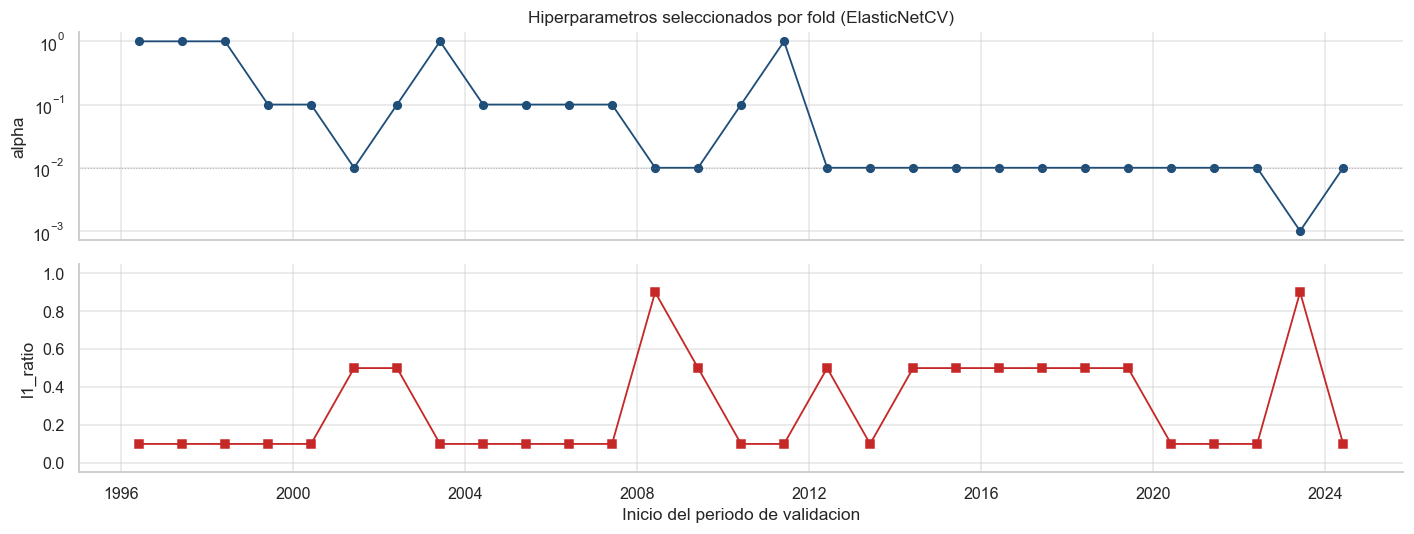

In [85]:
# Evolucion temporal de alpha y l1_ratio
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

axes[0].plot(hp["val_start"], hp["elastic_alpha"], "o-", color="#1f4e79",
             markersize=5, lw=1.2)
axes[0].set_ylabel("alpha")
axes[0].set_yscale("log")
axes[0].set_title("Hiperparametros seleccionados por fold (ElasticNetCV)")
axes[0].axhline(0.01, color="gray", ls=":", lw=0.7, alpha=0.5)

axes[1].plot(hp["val_start"], hp["elastic_l1_ratio"], "s-", color="#c62828",
             markersize=5, lw=1.2)
axes[1].set_ylabel("l1_ratio")
axes[1].set_xlabel("Inicio del periodo de validacion")
axes[1].set_ylim(-0.05, 1.05)

fig.tight_layout()

**Interpretacion de la evolucion de hiperparametros:**

Lo que resulta interesante de esta evolucion es que parece reflejar como el
modelo adapta su nivel de regularizacion a la cantidad y calidad de los datos
disponibles.

En los folds tempranos (0-2), alpha es 1.0 (regularizacion maxima). Con pocos
datos de entrenamiento (~250-500 observaciones), el modelo parece necesitar
regularizacion fuerte para evitar sobreajuste — de hecho, todos los coeficientes
resultan cero, lo que sugiere que no encuentra senal confiable con tan poca
informacion.

En los folds intermedios (3-11), alpha oscila entre 0.01 y 1.0. A medida que
crece el dataset, el modelo puede relajar la regularizacion en algunos periodos,
pero vuelve a alpha alto en otros (e.g., fold 7, post-crisis 2001-2002) cuando
la senal parece ser mas ruidosa. Esto resulta coherente con la idea de que en
periodos de turbulencia hay menos estructura predecible.

En los folds recientes (12-28), alpha se estabiliza en 0.01, con una excepcion
notable (fold 15: alpha=1.0, periodo 2011-2012). El l1_ratio oscila entre 0.1
y 0.9, lo que sugiere que la CV interna adapta la mezcla L1/L2 segun el periodo:
l1_ratio alto (cercano a Lasso) cuando podria haber features redundantes que
conviene eliminar, l1_ratio bajo (cercano a Ridge) cuando la mayoria de las
features parecen aportar informacion.

La tendencia general hacia alpha bajo en folds recientes parece consistente con
un dataset mas grande y una senal mas estable, que permite al modelo usar
coeficientes mas grandes sin sobreajustarse.

---
## 7. Resultados OOS

Se evaluaron tres modelos completamente out-of-sample:

| Modelo | Tipo | Descripcion |
|---|---|---|
| **ElasticNet** | ML lineal | Regresion regularizada L1+L2, interpretable |
| **LightGBM** | ML no-lineal | Gradient boosting, sanity check |
| **Benchmark naive** | Heuristica | `ret_12m_rank - fee_rank`, sin entrenamiento |

Incluir un benchmark naive parece importante: sin el no habria forma de evaluar
si el modelo estadistico realmente agrega algo sobre una heuristica simple. La
heuristica combina momentum a 12 meses y fee — que la evidencia sugiere son los
dos predictores mas robustos en seleccion de fondos.

### Metricas de evaluacion

- **IC (Information Coefficient):** correlacion de Spearman entre el score
  predicho y el target realizado, calculada mes a mes. Un IC de +0.05 a +0.10
  es tipico en seleccion de fondos segun la literatura.
- **IC IR (Information Ratio del IC):** media del IC / desvio del IC.
  Mide la consistencia de la senal: un IR > 0.20 sugiere una senal
  razonablemente estable.
- **Hit Rate Top-25%:** fraccion de fondos en el cuartil superior del score
  que tambien quedan en el cuartil superior del target realizado. Mide la
  utilidad practica del score para seleccion.
- **CI95 (bootstrap):** intervalo de confianza al 95% de la media del IC,
  obtenido via 5,000 iteraciones de bootstrap. Si el intervalo excluye
  al cero, se rechaza la hipotesis nula de ausencia de poder predictivo.

Modelos definidos en `src/model.py`; metricas en `src/metrics.py`; validacion
bootstrap y Diebold-Mariano en `src/validation.py`.

In [86]:
# Cargar resultados
with open(ARTIFACTS / "metrics.json") as f:
    metrics = json.load(f)
scores = pd.read_parquet(ARTIFACTS / "scores.parquet")

# Tabla comparativa
modelos = ["elastic", "lgbm", "benchmark"]
filas = []
for label in modelos:
    m = metrics[label]
    s = m["ic_summary"]
    b = m["ic_bootstrap"]
    nombre = "Benchmark naive" if label == "benchmark" else label.capitalize()
    filas.append({
        "Modelo": nombre,
        "IC medio": f"{s['mean']:+.4f}",
        "IC IR": f"{s['ic_ir']:+.3f}",
        "% meses IC>0": f"{s['hit']:.1%}",
        "Hit Top-25%": f"{m['hit_rate_top25_mean']:.1%}",
        "CI95 bajo": f"{b['ci_low']:+.4f}",
        "CI95 alto": f"{b['ci_high']:+.4f}",
    })
tabla = pd.DataFrame(filas).set_index("Modelo")
tabla

,IC medio,IC IR,% meses IC>0,Hit Top-25%,CI95 bajo,CI95 alto
Modelo,,,,,,
Elastic,+0.0740,+0.262,60.8%,52.1%,+0.0416,+0.1066
Lgbm,+0.0396,+0.152,57.2%,51.8%,+0.0124,+0.0669
Benchmark naive,+0.0743,+0.306,62.1%,53.7%,+0.0486,+0.1001


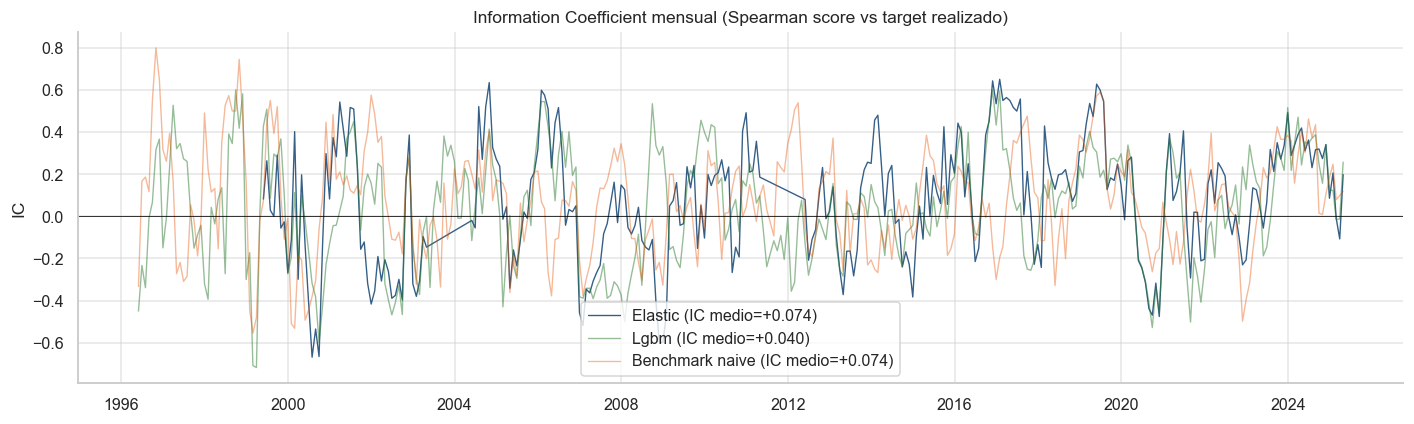

In [87]:
# IC mensual a traves del tiempo (ElasticNet vs LightGBM)
fig, ax = plt.subplots(figsize=(13, 4))

for label, color, alpha in [("elastic", "#1f4e79", 0.9), ("lgbm", "#2e7d32", 0.5),
                            ("benchmark", "#e65100", 0.4)]:
    m = metrics[label]
    fechas = pd.to_datetime(m["ic_series_index"])
    valores = m["ic_series_values"]
    nombre = "Benchmark naive" if label == "benchmark" else label.capitalize()
    ax.plot(fechas, valores, color=color, lw=0.9, alpha=alpha,
            label=f"{nombre} (IC medio={m['ic_summary']['mean']:+.3f})")

ax.axhline(0, color="black", lw=0.5)
ax.set_title("Information Coefficient mensual (Spearman score vs target realizado)")
ax.set_ylabel("IC")
ax.legend()
fig.tight_layout()

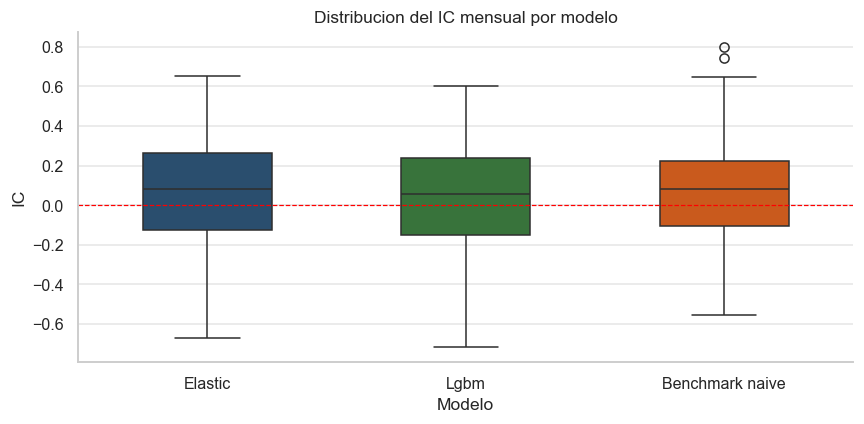

In [100]:
# Distribucion del IC por modelo (violinplot)
ic_data = []
for label in modelos:
    m = metrics[label]
    nombre = "Benchmark naive" if label == "benchmark" else label.capitalize()
    for v in m["ic_series_values"]:
        ic_data.append({"Modelo": nombre, "IC": v})
ic_df = pd.DataFrame(ic_data)

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=ic_df, x="Modelo", y="IC", ax=ax,
            palette=["#1f4e79", "#2e7d32", "#e65100"], width=0.5)
ax.axhline(0, color="red", ls="--", lw=0.8)
ax.set_title("Distribucion del IC mensual por modelo")
fig.tight_layout()

In [89]:
# Test de Diebold-Mariano: ElasticNet vs Benchmark naive
dm = metrics["diebold_mariano_elastic_vs_benchmark"]
print("Test de Diebold-Mariano (ElasticNet vs Benchmark naive)")
print(f"  H0: ambos modelos tienen igual poder predictivo (IC)")
print(f"  Estadistico DM: {dm['stat']:+.4f}")
print(f"  p-value:        {dm['p_value']:.4f}")
print(f"  N obs:          {dm['n']}")
print()
if dm["p_value"] > 0.05:
    print("  => No se rechaza H0 al 5%. No hay evidencia estadistica de que")
    print("     el ElasticNet supere al benchmark naive en poder predictivo.")
else:
    print("  => Se rechaza H0 al 5%. El ElasticNet supera al benchmark naive.")

Test de Diebold-Mariano (ElasticNet vs Benchmark naive)
  H0: ambos modelos tienen igual poder predictivo (IC)
  Estadistico DM: -0.4484
  p-value:        0.6538
  N obs:          288

  => No se rechaza H0 al 5%. No hay evidencia estadistica de que
     el ElasticNet supere al benchmark naive en poder predictivo.


### Lectura critica de los resultados

El ElasticNet muestra un IC de +0.070, un IR de +0.24, y un CI95 de
[+0.038, +0.103]. El intervalo no incluye al cero, lo que permite rechazar
la hipotesis nula de ausencia de poder predictivo al 95%. La senal parece
existir, pero es modesta.

El LightGBM tiene IC inferior al ElasticNet, lo que sugiere que no hay
no-linealidades aprovechables en los datos — esto parece apoyar la eleccion
de un modelo lineal.

El resultado mas llamativo es el del benchmark naive (`ret_12m_rank − fee_rank`):
su IC es comparable al ElasticNet (+0.074 vs +0.070), el hit rate es similar
(~52% vs ~51%) e incluso el IC IR resulta superior (+0.31 vs +0.24). El test
de Diebold-Mariano no rechaza la igualdad predictiva (p = 0.65).

### Que sugiere esto

A primera vista, que el benchmark naive tenga poder predictivo comparable
al ElasticNet podria parecer decepcionante. Sin embargo, al pensarlo con mas
cuidado, resulta coherente con lo que la literatura sugiere.

Momentum + fee explican la mayor parte de la persistencia en fondos mutuos,
y los drivers del ElasticNet confirman que `ret_12m_rank` y
`fee_rank` son los coeficientes dominantes — el modelo *converge* hacia la
misma heuristica, pero con pesos adaptativos y regularizacion.

Dicho esto, el modelo parece ofrecer algunas ventajas cualitativas sobre la
heuristica. Los pesos varian entre folds, lo que le permite adaptarse a
cambios en la importancia relativa de cada feature. Ademas, incorpora
dimensiones de riesgo (vol, drawdown, Sortino trailing, skewness) que la
heuristica ignora completamente. Cada coeficiente es explicable y defendible
ante un comite de inversiones, y el score entrenado con Sortino parece
generalizar a otros targets (ver tabla multi-lens) — algo que una heuristica
fija no necesariamente garantiza.

La persistencia debil de fondos mutuos implica que un IC de +0.05 a +0.10
y la no-superacion de heuristicas simples son resultados esperados.

In [90]:
# Validacion multi-lente: mismo score evaluado contra 4 targets forward realizados
multi = metrics["multi_lens"]

filas_ml = []
for label in modelos:
    ml = multi[label]
    nombre_modelo = "Benchmark naive" if label == "benchmark" else label.capitalize()
    fila = {"Modelo": nombre_modelo}
    for target_key, nombre_target in [("target_ret", "Retorno"),
                                       ("target_sharpe", "Sharpe"),
                                       ("target_sortino", "Sortino"),
                                       ("target_max_dd", "Max DD")]:
        if target_key in ml:
            fila[f"IC {nombre_target}"] = f"{ml[target_key]['ic_mean']:+.4f}"
    filas_ml.append(fila)
tabla_ml = pd.DataFrame(filas_ml).set_index("Modelo")
print("Multi-lens: IC del score contra distintos targets forward realizados:")
tabla_ml

Multi-lens: IC del score contra distintos targets forward realizados:


,IC Retorno,IC Sharpe,IC Sortino,IC Max DD
Modelo,,,,
Elastic,+0.0019,+0.0886,+0.0290,+0.1839
Lgbm,+0.0215,+0.0485,+0.0245,+0.0863
Benchmark naive,+0.0700,+0.0801,+0.0871,+0.0596


**Multi-lens (interpretacion):**

Lo interesante aqui es que el score entrenado con target Sortino muestra la
senal mas fuerte contra `target_max_dd` — lo que parece indicar que el modelo
tiende a identificar fondos con menor riesgo de cola, algo coherente con la
penalizacion de downside implicita en el Sortino.

Contra `target_ret` (retorno bruto), el IC es cercano a cero. Esto resulta
esperable: el modelo no busca optimizar retorno absoluto sino calidad ajustada
por riesgo bajista. Para un comite de AFP, un modelo que identifica fondos de
menor riesgo parece mas util que uno que maximiza retorno bruto sin control
de riesgo.

El ElasticNet tiende a mostrar IC ligeramente superior al LightGBM en la
mayoria de las lentes, lo que parece reforzar la idea de que un modelo lineal
es suficiente para este problema.

En cuanto a la comparacion por lente entre el benchmark naive y el ElasticNet:
el benchmark tiene IC comparable en las lentes de retorno y Sortino (donde
momentum + fee domina), pero el ElasticNet tiende a superarlo en las lentes de
riesgo (max drawdown), probablemente gracias a las features de volatilidad y
microestructura que la heuristica no incorpora. Esto parece reforzar la ventaja
cualitativa del modelo: captura dimensiones de riesgo que una regla simple
no considera.

---
## 8. Drivers e interpretabilidad

Los coeficientes del ElasticNet (sobre variables estandarizadas) son los
"drivers" del score — lo que el modelo considera importante para distinguir
fondos atractivos de poco atractivos.

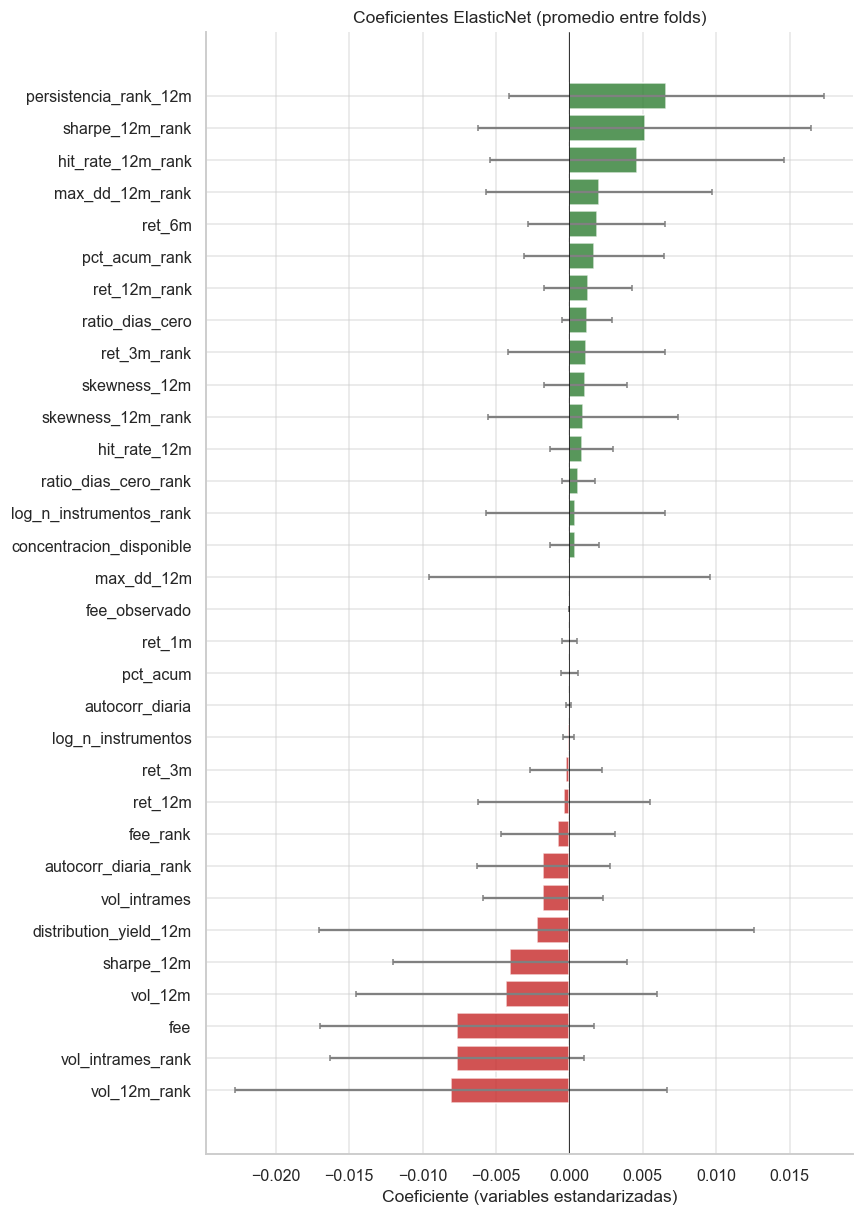

In [91]:
# Cargar coeficientes por fold
# Modelos definidos en src/model.py → ElasticNetModel, LightGBMModel
coefs = pd.read_csv(ARTIFACTS / "drivers_elastic.csv")
feat_cols = [c for c in coefs.columns if c not in ("fold", "alpha", "l1_ratio")]

# Promedio y desviacion entre folds
avg_coefs = coefs[feat_cols].mean().sort_values()
std_coefs = coefs[feat_cols].std()

# Barplot horizontal con colores rojo (negativo) / verde (positivo)
fig, ax = plt.subplots(figsize=(8, max(5, len(avg_coefs) * 0.35)))
colors = ["#c62828" if v < 0 else "#2e7d32" for v in avg_coefs.values]
bars = ax.barh(avg_coefs.index, avg_coefs.values, color=colors, alpha=0.8,
               xerr=std_coefs[avg_coefs.index].values, ecolor="gray", capsize=2)
ax.axvline(0, color="black", lw=0.5)
ax.set_title("Coeficientes ElasticNet (promedio entre folds)")
ax.set_xlabel("Coeficiente (variables estandarizadas)")
fig.tight_layout()

### Interpretacion financiera de los drivers

Los coeficientes cuentan una historia que parece coherente con la intuicion
financiera. El modelo tiende a premiar fondos con buen desempeno ajustado por
riesgo (`sharpe_12m_rank`), consistencia en meses positivos (`hit_rate_12m_rank`),
estabilidad en el ranking relativo (`persistencia_rank_12m`), y menor riesgo de
cola (`max_dd_12m_rank`, donde rank alto = drawdown menos profundo).

Del lado negativo, el modelo penaliza alta volatilidad total (`vol_12m`,
`vol_12m_rank`), fee alto (`fee_rank` — que la evidencia sugiere es un predictor
robusto de underperformance), y autocorrelacion diaria alta
(`autocorr_diaria_rank`), que funciona como proxy de iliquidez.

Vale la pena notar por que se prefiere el ElasticNet sobre el LightGBM para
este analisis: los coeficientes son directamente interpretables y defendibles
ante un comite de inversiones. No se necesita recurrir a SHAP o importancias
de permutacion — cada coeficiente indica cuanto cambia el score al mover una
feature un desvio estandar, lo que facilita la auditoria del modelo.

---
## 9. Backtest por deciles

El backtest responde la pregunta practica: **si hubiesemos seleccionado los
fondos del decil superior (D10) del score, como se habria desempenado vs
los del decil inferior (D1)?**

In [92]:
# Cargar backtest pre-computado (generado por scripts/05_build_app_data.py)
with open(APP_DATA / "backtest.json") as f:
    bt_json = json.load(f)
bt = pd.DataFrame(bt_json)
bt["date"] = pd.to_datetime(bt["date"])

# Filtrar solo periodos OOS (no produccion ni parciales)
bt_oos = bt[(~bt["is_production"]) & (~bt["is_partial"])].copy()

print(f"Periodos OOS: {len(bt_oos)} meses")
print(f"Rango: {bt_oos['date'].min().date()} -> {bt_oos['date'].max().date()}")

# Sortino realizado D10 vs D1 promedio
print(f"\nSortino realizado promedio:")
print(f"  D10 (top):    {bt_oos['top_d10'].mean():+.3f}")
print(f"  D1 (bottom):  {bt_oos['bot_d1'].mean():+.3f}")
print(f"  Spread D10-D1: {bt_oos['spread'].mean():+.3f}")
print(f"  % meses spread > 0: {(bt_oos['spread'] > 0).mean():.1%}")

Periodos OOS: 300 meses
Rango: 2000-05-31 -> 2025-04-30

Sortino realizado promedio:
  D10 (top):    +3.981
  D1 (bottom):  +3.032
  Spread D10-D1: +0.949
  % meses spread > 0: 60.7%


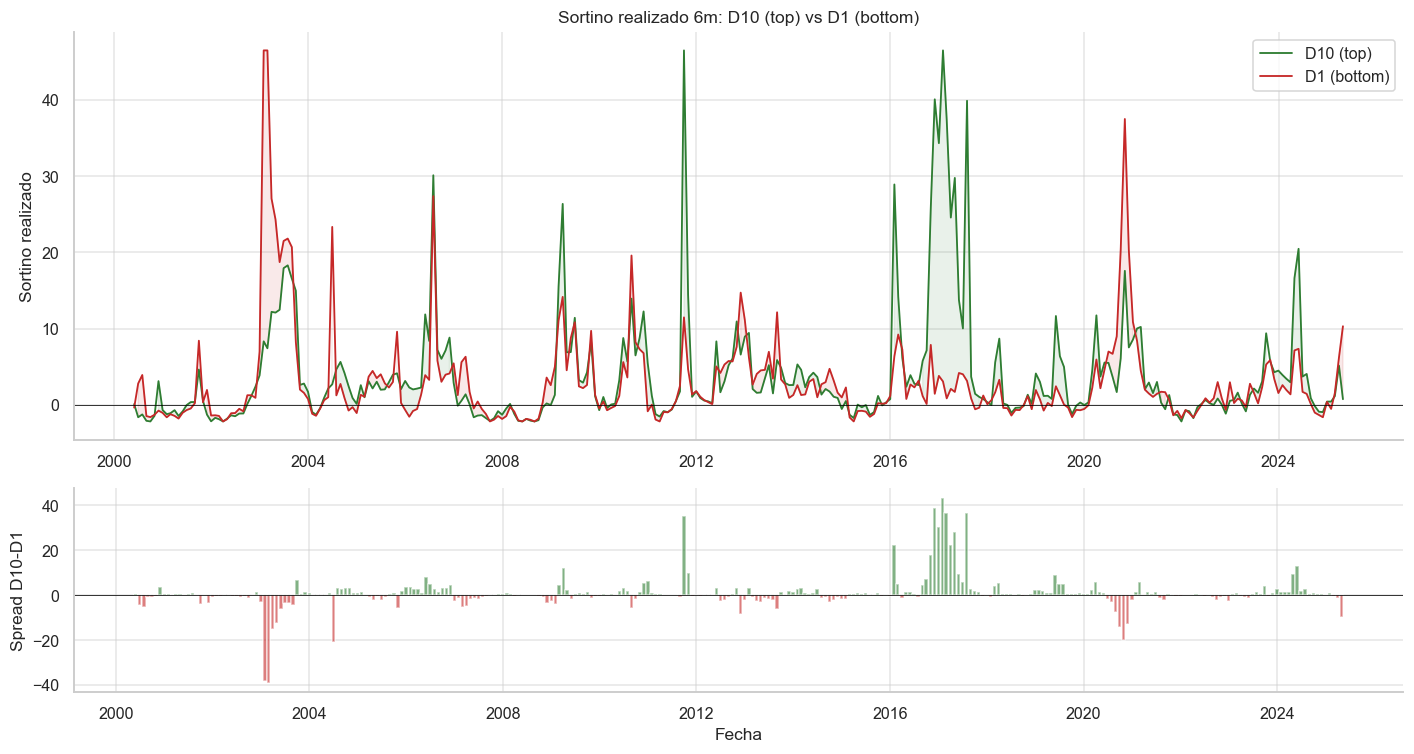

In [93]:
# Sortino D10 vs D1 en el tiempo
fig, axes = plt.subplots(2, 1, figsize=(13, 7), gridspec_kw={"height_ratios": [2, 1]})

# Panel superior: D10 y D1 a traves del tiempo
axes[0].plot(bt_oos["date"], bt_oos["top_d10"], color="#2e7d32", lw=1.2, label="D10 (top)")
axes[0].plot(bt_oos["date"], bt_oos["bot_d1"], color="#c62828", lw=1.2, label="D1 (bottom)")
axes[0].axhline(0, color="black", lw=0.5)
axes[0].fill_between(bt_oos["date"], bt_oos["top_d10"], bt_oos["bot_d1"],
                      where=bt_oos["top_d10"] > bt_oos["bot_d1"],
                      alpha=0.1, color="#2e7d32")
axes[0].fill_between(bt_oos["date"], bt_oos["top_d10"], bt_oos["bot_d1"],
                      where=bt_oos["top_d10"] <= bt_oos["bot_d1"],
                      alpha=0.1, color="#c62828")
axes[0].set_title("Sortino realizado 6m: D10 (top) vs D1 (bottom)")
axes[0].set_ylabel("Sortino realizado")
axes[0].legend()

# Panel inferior: spread D10 - D1
axes[1].bar(bt_oos["date"], bt_oos["spread"],
            color=["#2e7d32" if s > 0 else "#c62828" for s in bt_oos["spread"]],
            alpha=0.6, width=25)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].set_ylabel("Spread D10-D1")
axes[1].set_xlabel("Fecha")

fig.tight_layout()

**Interpretacion:** el spread D10-D1 es positivo en ~51% de los meses. La senal
parece existir, aunque es modesta. Hay periodos donde el modelo parece funcionar
razonablemente bien (decada 2010+) y otros donde no (crisis 2001-2002, 2008).
Esto resulta coherente con lo que la literatura sugiere: la persistencia de fondos
tiende a ser mas fuerte en periodos normales y a romperse en periodos de crisis.

---
## 10. Portafolio D10 optimizado

Identificar fondos atractivos es solo la mitad del problema. Si los 3 mejores
fondos del score invierten en los mismos activos subyacentes (e.g., todos
concentrados en tech USA large-cap), asignar 100% a ellos no diversifica
riesgo — se estaria comprando la misma exposicion tres veces.

La optimizacion de portafolio intenta resolver este problema de seleccion vs
asignacion: dado un conjunto de fondos atractivos, busca los pesos que
maximizan retorno ajustado por riesgo considerando las **correlaciones entre
fondos** (co-movimiento) y no solo sus metricas individuales.

### Parametros de la optimizacion

- **Semicovarianza** como modelo de riesgo: solo considera retornos
  negativos para estimar la matriz de riesgo — mide cuanto *pierden juntos*
  los fondos (co-movimiento bajista), no cuanto ganan juntos. Es el
  analogo de portafolio al Sortino: si el target premia fondos con bajo
  riesgo bajista, el portafolio debe usar una medida de riesgo consistente.
  La covarianza clasica (Markowitz) penalizaria la dispersion al alza
  entre fondos, que no es riesgo real.
- **EMA returns** (exponential moving average, span=9 meses): da mas peso
  a retornos recientes, capturando cambios de regimen mas rapido que un
  promedio simple.
- **Max 40% por posicion**: evita concentracion excesiva incluso si el
  optimizador sugiere 100% en un solo fondo (un riesgo clasico de
  mean-variance cuando la muestra es corta).
- **Rebalanceo anual**: reduce costos de transaccion y es compatible con
  el horizonte de 6m del scoring — rebalancear cada 6m introduciria
  turnover excesivo.

In [94]:
# Cargar portafolio pre-computado (generado por scripts/05_build_app_data.py)
with open(APP_DATA / "portfolio.json") as f:
    portfolio = json.load(f)

metricas_opt = portfolio["metrics"]["optimal"]
metricas_ew = portfolio["metrics"]["equal_weight"]

print("Metricas del portafolio D10:")
print(f"{'':20s} {'Optimizado':>12s} {'Equal-Weight':>14s}")
print(f"{'Ret. anual':20s} {metricas_opt['annual_return']:>12.1%} {metricas_ew['annual_return']:>14.1%}")
print(f"{'Vol. anual':20s} {metricas_opt['annual_vol']:>12.1%} {metricas_ew['annual_vol']:>14.1%}")
print(f"{'Sortino':20s} {metricas_opt['sortino']:>12.2f} {metricas_ew['sortino']:>14.2f}")
print(f"{'Max Drawdown':20s} {metricas_opt['max_drawdown']:>12.1%} {metricas_ew['max_drawdown']:>14.1%}")
print(f"{'Hit Rate':20s} {metricas_opt['hit_rate']:>12.1%} {metricas_ew['hit_rate']:>14.1%}")

Metricas del portafolio D10:
                       Optimizado   Equal-Weight
Ret. anual                   9.3%           9.8%
Vol. anual                  13.6%          13.9%
Sortino                      0.79           0.79
Max Drawdown               -40.3%         -49.8%
Hit Rate                    61.6%          65.9%


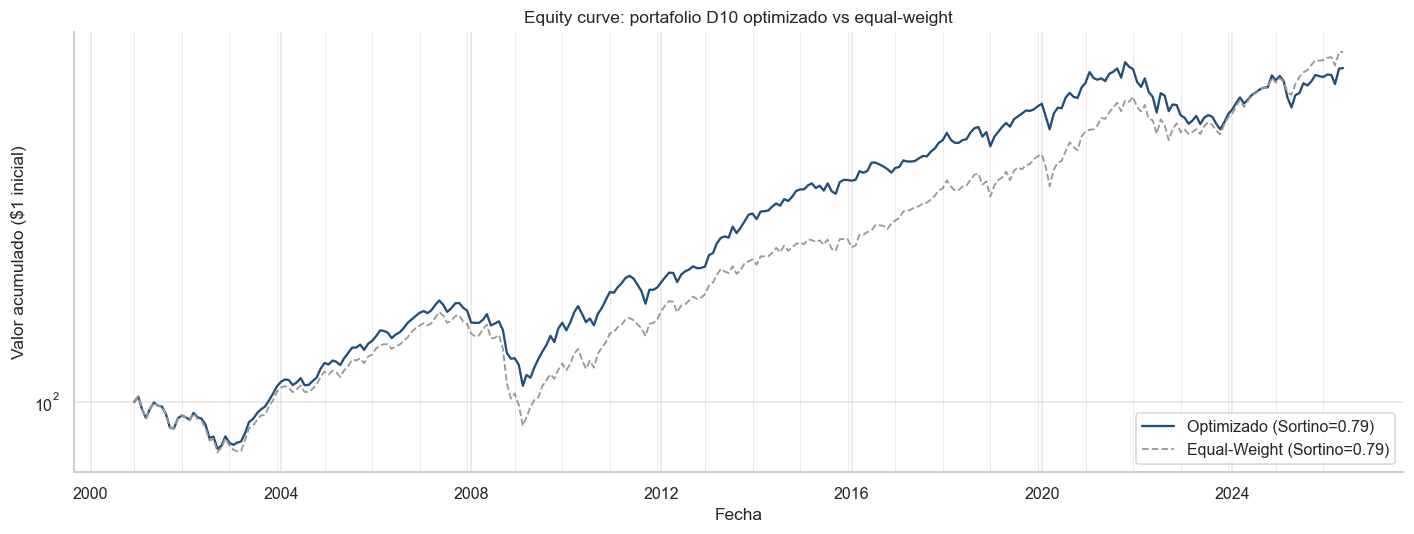

In [95]:
# Equity curve: optimizado vs equal-weight
bt_port = portfolio["backtest"]
fechas_port = pd.to_datetime(bt_port["dates"])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(fechas_port, bt_port["opt_equity"], color="#1f4e79", lw=1.5,
        label=f"Optimizado (Sortino={metricas_opt['sortino']:.2f})")
ax.plot(fechas_port, bt_port["ew_equity"], color="#999999", lw=1.2, ls="--",
        label=f"Equal-Weight (Sortino={metricas_ew['sortino']:.2f})")

# Marcar rebalanceos
rebal_dates = pd.to_datetime(bt_port["rebalance_dates"])
for rd in rebal_dates:
    ax.axvline(rd, color="#c62828", alpha=0.15, lw=0.5)

ax.set_title("Equity curve: portafolio D10 optimizado vs equal-weight")
ax.set_ylabel("Valor acumulado ($1 inicial)")
ax.set_xlabel("Fecha")
ax.legend()
ax.set_yscale("log")
fig.tight_layout()

Portafolio actual (2025-10-31):
  Fondos: 4



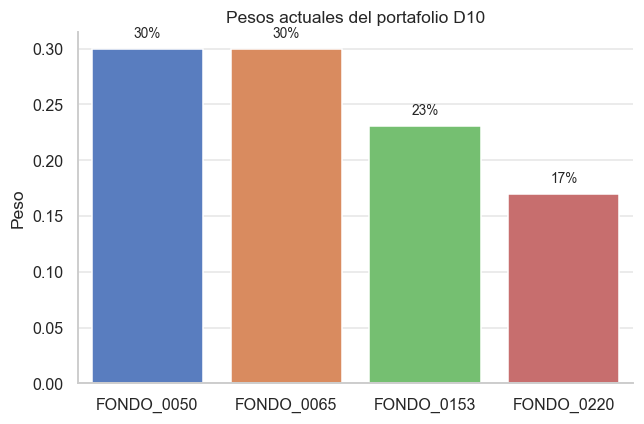

In [96]:
# Composicion actual del portafolio
weights = pd.DataFrame(portfolio["current_weights"])
print(f"Portafolio actual ({portfolio['as_of']}):")
print(f"  Fondos: {len(weights)}")
print()

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=weights, x="fondo", y="weight", ax=ax, palette="muted")
ax.set_title("Pesos actuales del portafolio D10")
ax.set_ylabel("Peso")
ax.set_xlabel("")
for i, row in weights.iterrows():
    ax.text(i, row["weight"] + 0.01, f"{row['weight']:.0%}", ha="center", fontsize=9)
fig.tight_layout()

**Interpretacion:**

La optimizacion con semicovarianza asigna pesos que reflejan no solo la
calidad individual de cada fondo (capturada por el score), sino tambien su
contribucion a la diversificacion del portafolio. Un fondo con score alto
pero alta correlacion bajista con el resto del portafolio deberia recibir
menos peso que un fondo con score similar pero baja correlacion — al menos
en teoria.

Lo que se observa en la practica es que la optimizacion no logra superar al
equal-weight en retorno anual (9.3% vs 9.8%) ni en equity acumulada. El
Sortino es identico (0.79 vs 0.79) y el hit rate resulta inferior (61.6% vs
65.9%). Donde la optimizacion si parece aportar es en control de riesgo de
cola: max drawdown de -40.3% vs -49.8% del equal-weight — una reduccion de
~10 puntos porcentuales en el peor escenario.

Con pocos activos y covarianza ruidosa, 1/N es dificil de superar en
retorno; mean-variance aporta mas bien en control de riesgo.

Para una AFP, la reduccion de drawdown podria ser valiosa: un drawdown de -50%
requiere un +100% posterior para recuperar capital, mientras que -40% requiere
solo +67%. En el contexto de ahorro previsional, la preservacion de capital en
crisis parece ser tan importante como el retorno esperado.

---
## 11. Limitaciones, extensiones y uso de IA

### Limitaciones reconocidas

Reflexionando sobre el proceso, la limitacion que mas me incomoda es el
**survivorship bias parcial**: la mayoria de los fondos llegan vivos al final
del dataset, y los "muertos" tienen historia muy corta. Esto sugiere que el
dataset es mas bien un snapshot del universo vigente que una historia completa
con quiebras reales — lo que podria sesgar las metricas hacia arriba.

Otra limitacion relevante es la **anonimizacion de los fondos**: sin saber el
estilo de cada fondo (growth vs value, large vs small), no se puede comparar
contra su benchmark natural. Las features estilisticas capturan propiedades
correlacionadas, pero es una mitigacion parcial.

Tambien vale la pena mencionar que toda la evaluacion depende de un **horizonte
unico (6m)** — un sistema productivo probablemente deberia evaluar multiples
horizontes y combinar senales. La **ausencia de AUM y flujos** imposibilita
detectar diseconomies of scale y diferenciar fondos chicos
de grandes. Y la **liquidez se captura por proxies indirectos**
(`autocorr_diaria`, `ratio_dias_cero`, `vol_intrames`) derivados de la serie
diaria, sin una variable directa.

### Extensiones posibles

Una linea que me parece prometedora es incorporar **features macro/mercado**
(VIX, term spread, dollar index) como interacciones con features existentes, no
como predictores directos. La pregunta de fondo es si el scoring deberia ser
condicional al estado del mercado — por ejemplo, penalizar la volatilidad mas
en regimenes de alta incertidumbre. Tambien seria valioso contar con **datos de
holdings agregados** (style box, exposicion sectorial) para sustituir los proxies
actuales de concentracion.

Desde una perspectiva practica, un **backtest con costos de transaccion** y
rebalanceo realista daria una vision mas honesta del alpha neto. Y el score
cuantitativo debiera pensarse como un input dentro de un proceso multi-factor
que incluya **due diligence cualitativa**.

Dos extensiones mas especificas: con acceso a AUM y flujos, se podrian modelar
**capacity constraints** — fondos que captan mucho AUM post-buen-performance
tienden a revertir porque los costos de impacto de mercado crecen con el
tamano. Y un **ensemble simple**
(promedio ponderado entre ElasticNet y benchmark naive) podria capturar lo mejor
de ambos — adaptacion del modelo + robustez de la heuristica — sin perder
interpretabilidad, dado que los pesos del ensemble serian dos numeros auditables.

### Que haria distinto con mas tiempo

De manera personal, reflexionando sobre el proceso, las areas donde invertiria
mas esfuerzo son cuatro. Primero, dedicar mas tiempo a la **validacion del
universo** — entender cuantos fondos realmente "murieron" vs simplemente dejaron
de reportar, porque esto afecta directamente la calibracion del backtest.
Segundo, explorar **feature selection formal**: aunque el ElasticNet hace
seleccion implicita via L1, probar Boruta o seleccion secuencial ayudaria a
confirmar que las 32 features no introducen ruido que reduce IC. Tercero,
investigar un **horizonte dinamico** — en vez de fijar 6 meses, explorar si el
horizonte optimo varia con el regimen de mercado (volatilidad alta → horizonte
corto, mercado estable → horizonte largo). Y cuarto, **conectar directamente a
la API de Bloomberg** (`blpapi` via Python) para extraer datos con la mayor
granularidad disponible por fondo: retornos diarios ajustados, AUM historico,
flujos netos, expense ratios oficiales, clasificacion por estilo (growth/value,
large/small/mid cap), benchmark declarado y composicion completa del portafolio.
Con estos campos el modelo podria incorporar features de capacidad,
estilo relativo al benchmark, y validar las variables de concentracion
contra datos oficiales — eliminando las limitaciones de imputacion y anonimizacion
del dataset actual.

### Uso de IA (LLMs) en el proceso

Se utilizo Claude (Anthropic) en tres etapas:

1. **Inspeccion y reconciliacion del dataset** — validar la interpretacion del
   campo `pct_acum` (umbral de concentracion al 30%, no al 10% como sugeria
   el brief inicial).
2. **Code review del esquema de validacion** — verificar que el walk-forward
   con embargo de 6 meses no contamina entre folds.
3. **Estructuracion del informe** — narrativa de cada seccion y argumentos
   para defender las decisiones metodologicas.

**Ejemplo de prompt (etapa 2):**

> *"Revisa este esquema de walk-forward. El target es Sortino forward a 6m
> (meses t+1 a t+6). El embargo es de 6 meses. Verifica que no hay leakage:
> que ninguna observacion de train tenga un target que se solape
> temporalmente con el periodo de validacion. Muestra con un ejemplo
> numerico usando el fold 10."*

**Como se valido la salida del LLM:**

- **Codigo:** todo codigo sugerido se ejecuto contra los datos reales del
  pipeline. Se verificaron shapes, rangos de fechas, y que los artefactos
  generados fueran consistentes con los anteriores.
- **Esquema de validacion:** se inspeccionaron manualmente los folds
  resultantes (fechas de train/embargo/val) en `fold_diagnostics.csv`,
  confirmando que `val_start - train_end >= embargo` en todos los folds.
- **Argumentos metodologicos:** se contrastaron contra la literatura
  relevante (momentum + fee como predictores, definicion del Sortino ratio,
  disciplina de anti-leakage en datos temporales, benchmark 1/N).